In [1]:
# Data Wrangling
import numpy as np
import pandas as pd

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Date Functionality
import matplotlib.dates as mdates

# Statistics
from statistics import stdev
from scipy.stats import t

# Remove Warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Loading Data
df1 = pd.read_csv("QVI_consolidated_data.csv")
df1

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,pack_size,Brand Name,LIFESTAGE,PREMIUM_CUSTOMER,PRICE
0,2018-10-17,1,1000,1,5,Natural Chip Company SeaSalt175g,2,6.0,175,Natural,YOUNG SINGLES/COUPLES,Premium,3.00
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175,CCs,MIDAGE SINGLES/COUPLES,Budget,2.10
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170,Smiths,MIDAGE SINGLES/COUPLES,Budget,1.45
3,2019-05-16,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7,330,Smiths,MIDAGE SINGLES/COUPLES,Budget,5.70
4,2019-05-16,4,4196,3539,24,Grain Waves Sweet Chilli 210g,1,3.6,210,Grain,MIDAGE SINGLES/COUPLES,Budget,3.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...
246068,2019-03-09,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8,175,Kettle,YOUNG SINGLES/COUPLES,Premium,5.40
246069,2018-08-13,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4,175,Tostitos,YOUNG SINGLES/COUPLES,Premium,4.40
246070,2018-11-06,272,272379,270187,51,Doritos Mexicana 170g,2,8.8,170,Doritos,YOUNG SINGLES/COUPLES,Premium,4.40
246071,2018-12-27,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8,150,Doritos,YOUNG SINGLES/COUPLES,Premium,3.90


**To Check Missing Data**

In [3]:
df1.isnull().sum()

,0
DATE,0
STORE_NBR,0
LYLTY_CARD_NBR,0
TXN_ID,0
PROD_NBR,0
PROD_NAME,0
PROD_QTY,0
TOT_SALES,0
pack_size,0
Brand Name,0


**Select control stores**

*The client has selected store numbers 77, 86 and 88 as trial stores and want control stores to be established stores that are operational for the entire observation period. We would want to match trial stores to control stores that are similar to the trial store prior to the trial period of Feb 2019 in terms of :*

* Monthly overall sales revenue
* Monthly number of customers
* Monthly number of transactions per customer

In [4]:
#### Create a month ID in format yyyymm

df1['YEARMONTH'] = [''.join(x.split('-')[0:2]) for x in df1.DATE]
df1['YEARMONTH'] = pd.to_numeric(df1['YEARMONTH'])
df1['YEARMONTH']

,YEARMONTH
0,201810
1,201905
2,201905
3,201905
4,201905
...,...
246068,201903
246069,201808
246070,201811
246071,201812


**For each store and month calculate**

* Total sales.
* Number of customers.
* Transactions per customer.
* Chips per customer.
* Average price per unit.

In [5]:
# Total Sales for each store and month.

Total_Sales= df1.groupby(['STORE_NBR', 'YEARMONTH']).TOT_SALES.sum()
Total_Sales


STORE_NBR  YEARMONTH
1          201807       188.9
           201808       168.4
           201809       268.1
           201810       175.4
           201811       184.8
                        ...  
272        201902       385.3
           201903       421.9
           201904       445.1
           201905       314.6
           201906       301.9
Name: TOT_SALES, Length: 3165, dtype: float64

In [6]:
# Number of customers for each store and month.

no_Customers = df1.groupby(['STORE_NBR', 'YEARMONTH']).LYLTY_CARD_NBR.nunique()
no_Customers

STORE_NBR  YEARMONTH
1          201807       47
           201808       41
           201809       57
           201810       39
           201811       44
                        ..
272        201902       44
           201903       48
           201904       54
           201905       34
           201906       33
Name: LYLTY_CARD_NBR, Length: 3165, dtype: int64

In [7]:
# Transactions per customer for each store and month.

trans_per_customer = df1.groupby(['STORE_NBR', 'YEARMONTH']).TXN_ID.nunique()/df1.groupby(['STORE_NBR', 'YEARMONTH']).LYLTY_CARD_NBR.nunique()
trans_per_customer

STORE_NBR  YEARMONTH
1          201807       1.042553
           201808       1.000000
           201809       1.035088
           201810       1.025641
           201811       1.022727
                          ...   
272        201902       1.068182
           201903       1.062500
           201904       1.018519
           201905       1.176471
           201906       1.090909
Length: 3165, dtype: float64

In [8]:
# Chips per customer for each store and month.

chips_per_customer = df1.groupby(['STORE_NBR', 'YEARMONTH']).PROD_QTY.sum()/ df1.groupby(['STORE_NBR', 'YEARMONTH']).TXN_ID.nunique()
chips_per_customer

STORE_NBR  YEARMONTH
1          201807       1.183673
           201808       1.268293
           201809       1.203390
           201810       1.275000
           201811       1.222222
                          ...   
272        201902       1.893617
           201903       1.901961
           201904       1.909091
           201905       1.775000
           201906       1.888889
Length: 3165, dtype: float64

In [9]:
# Average price per unit for each store and month.

average_price = df1.groupby(['STORE_NBR', 'YEARMONTH']).TOT_SALES.sum()/ df1.groupby(['STORE_NBR', 'YEARMONTH']).PROD_QTY.sum()
average_price

STORE_NBR  YEARMONTH
1          201807       3.256897
           201808       3.238462
           201809       3.776056
           201810       3.439216
           201811       3.360000
                          ...   
272        201902       4.329213
           201903       4.349485
           201904       4.239048
           201905       4.430986
           201906       4.439706
Length: 3165, dtype: float64

In [10]:
# Concatenate into a new dataframe 'measureOverTime'

df2 = [Total_Sales, no_Customers, trans_per_customer, chips_per_customer, average_price]
measureOverTime = pd.concat(df2, join = 'outer', axis = 1)
measureOverTime

TOT_SALES  LYLTY_CARD_NBR         0         1         2
STORE_NBR YEARMONTH                                                         
1         201807         188.9              47  1.042553  1.183673  3.256897
          201808         168.4              41  1.000000  1.268293  3.238462
          201809         268.1              57  1.035088  1.203390  3.776056
          201810         175.4              39  1.025641  1.275000  3.439216
          201811         184.8              44  1.022727  1.222222  3.360000
...                        ...             ...       ...       ...       ...
272       201902         385.3              44  1.068182  1.893617  4.329213
          201903         421.9              48  1.062500  1.901961  4.349485
          201904         445.1              54  1.018519  1.909091  4.239048
          201905         314.6              34  1.176471  1.775000  4.430986
          201906         301.9              33  1.090909  1.888889  4.439706

[3165 rows x 5 columns]

In [11]:
# Rename the columns

measureOverTime.rename(columns = {'TOT_SALES': 'Total Sales', 'LYLTY_CARD_NBR': 'no_Customers', 0: 'trans_per_customer', 1: 'chips_per_customer', 2: 'average_price'}, inplace = True)
measureOverTime.head(15)

Total Sales  no_Customers  trans_per_customer  \
STORE_NBR YEARMONTH                                                  
1         201807           188.9            47            1.042553   
          201808           168.4            41            1.000000   
          201809           268.1            57            1.035088   
          201810           175.4            39            1.025641   
          201811           184.8            44            1.022727   
          201812           160.6            37            1.081081   
          201901           149.7            35            1.000000   
          201902           194.7            49            1.040816   
          201903           185.2            43            1.093023   
          201904           177.4            39            1.025641   
          201905           207.1            43            1.116279   
          201906           163.6            39            1.000000   
2         201807           140.5            36            1.055556   
          201808           152.1            33            1.121212   
          201809           133.9            32            1.031250   

                     chips_per_customer  average_price  
STORE_NBR YEARMONTH                                     
1         201807               1.183673       3.256897  
          201808               1.268293       3.238462  
          201809               1.203390       3.776056  
          201810               1.275000       3.439216  
          201811               1.222222       3.360000  
          201812               1.200000       3.345833  
          201901               1.171429       3.651220  
          201902               1.137255       3.356897  
          201903               1.191489       3.307143  
          201904               1.300000       3.411538  
          201905               1.291667       3.340323  
          201906               1.282051       3.272000  
2         201807               1.131579       3.267442  
          201808               1.135135       3.621429  
          201809               1.090909       3.719444

In [12]:
measureOverTime.reset_index(inplace = True)
measureOverTime

,STORE_NBR,YEARMONTH,Total Sales,no_Customers,trans_per_customer,chips_per_customer,average_price
0,1,201807,188.9,47,1.042553,1.183673,3.256897
1,1,201808,168.4,41,1.000000,1.268293,3.238462
2,1,201809,268.1,57,1.035088,1.203390,3.776056
3,1,201810,175.4,39,1.025641,1.275000,3.439216
4,1,201811,184.8,44,1.022727,1.222222,3.360000
...,...,...,...,...,...,...,...
3160,272,201902,385.3,44,1.068182,1.893617,4.329213
3161,272,201903,421.9,48,1.062500,1.901961,4.349485
3162,272,201904,445.1,54,1.018519,1.909091,4.239048
3163,272,201905,314.6,34,1.176471,1.775000,4.430986


In [13]:
#### Filter to the pre-trial period and stores with full observation periods

df3 = pd.pivot_table(df1, index = 'STORE_NBR', columns = 'YEARMONTH', values = 'TXN_ID', aggfunc = 'count')
df3

YEARMONTH,201807,201808,201809,201810,201811,201812,201901,201902,201903,201904,201905,201906
STORE_NBR,,,,,,,,,,,,
1,49.0,41.0,59.0,40.0,45.0,40.0,35.0,51.0,47.0,40.0,48.0,40.0
2,38.0,37.0,33.0,41.0,34.0,35.0,43.0,31.0,41.0,45.0,47.0,38.0
3,134.0,124.0,118.0,117.0,111.0,124.0,114.0,134.0,126.0,102.0,113.0,117.0
4,152.0,143.0,135.0,148.0,127.0,128.0,156.0,97.0,127.0,130.0,110.0,129.0
5,111.0,98.0,122.0,98.0,103.0,112.0,108.0,103.0,86.0,101.0,92.0,117.0
...,...,...,...,...,...,...,...,...,...,...,...,...
268,50.0,47.0,30.0,46.0,46.0,39.0,35.0,36.0,44.0,45.0,48.0,38.0
269,131.0,124.0,117.0,142.0,125.0,119.0,133.0,123.0,117.0,129.0,114.0,114.0
270,124.0,142.0,115.0,104.0,121.0,140.0,146.0,116.0,137.0,122.0,117.0,114.0


In [14]:
# Store numbers that do not have full observation periods

null_stores = df3[df3.isnull().any(axis=1)].index.tolist()
null_stores

[11, 31, 44, 76, 85, 92, 117, 177, 193, 206, 218, 252]

In [15]:
# Filter out the null stores

measureOverTime = measureOverTime[~measureOverTime['STORE_NBR'].isin(null_stores)]
measureOverTime

,STORE_NBR,YEARMONTH,Total Sales,no_Customers,trans_per_customer,chips_per_customer,average_price
0,1,201807,188.9,47,1.042553,1.183673,3.256897
1,1,201808,168.4,41,1.000000,1.268293,3.238462
2,1,201809,268.1,57,1.035088,1.203390,3.776056
3,1,201810,175.4,39,1.025641,1.275000,3.439216
4,1,201811,184.8,44,1.022727,1.222222,3.360000
...,...,...,...,...,...,...,...
3160,272,201902,385.3,44,1.068182,1.893617,4.329213
3161,272,201903,421.9,48,1.062500,1.901961,4.349485
3162,272,201904,445.1,54,1.018519,1.909091,4.239048
3163,272,201905,314.6,34,1.176471,1.775000,4.430986


In [16]:
# Filter to pre-trial period before 201902
preTrialMeasures = measureOverTime[measureOverTime['YEARMONTH'] < 201902]
preTrialMeasures

,STORE_NBR,YEARMONTH,Total Sales,no_Customers,trans_per_customer,chips_per_customer,average_price
0,1,201807,188.9,47,1.042553,1.183673,3.256897
1,1,201808,168.4,41,1.000000,1.268293,3.238462
2,1,201809,268.1,57,1.035088,1.203390,3.776056
3,1,201810,175.4,39,1.025641,1.275000,3.439216
4,1,201811,184.8,44,1.022727,1.222222,3.360000
...,...,...,...,...,...,...,...
3155,272,201809,294.5,31,1.129032,1.971429,4.268116
3156,272,201810,405.1,41,1.146341,2.000000,4.309574
3157,272,201811,355.8,39,1.102564,1.930233,4.286747
3158,272,201812,363.1,43,1.000000,1.883721,4.482716


# Now we need to work out a way of ranking how similar each potential control store is to the trial store. We can calculate how correlated the performance of each store is to the trial store.

In [17]:
#Let's write a function for this so that we don't have to calculate this for each trial store and control store pair.
#### Create a function to calculate correlation for a measure

def calculateCorrelation(inputTable, metricCol, storeComparison):
    calcCorrTable = pd.DataFrame({'Store1': [], 'Store2': [], 'corr_measure': []})
    x = inputTable.loc[inputTable['STORE_NBR'] == trial_store, metricCol]
    x.reset_index(drop = True, inplace = True)
    storeNumbers = inputTable['STORE_NBR'].unique()
    for i in storeNumbers:
        y = inputTable.loc[inputTable['STORE_NBR'] == i, metricCol]
        y.reset_index(drop = True, inplace = True)
        calcCorrTable = calcCorrTable.append({'Store1': trial_store, 'Store2': i, 'corr_measure': y.corr(x)}, ignore_index = True)
    return calcCorrTable

**Apart from correlation, we can also calculate a standardised metric based on the absolute difference between the trial store's performance and each control store's performance**

In [18]:
def calculateMagnitudeDistance(inputTable, metricCol, storeComparison):
    calcDistTable = pd.DataFrame({'Store1': [], 'Store2': [], 'Magnitude' : []})
    x = inputTable.loc[inputTable['STORE_NBR'] == trial_store, metricCol]
    x.reset_index(drop = True, inplace = True)
    storeNumbers = inputTable['STORE_NBR'].unique()
    for i in storeNumbers:
        y = inputTable.loc[inputTable['STORE_NBR'] == i, metricCol]
        y.reset_index(drop = True, inplace = True)
        z = abs(x-y)
        A = np.mean(1-(z-min(z))/(max(z)-min(z)))
        calcDistTable = calcDistTable.append({'Store1': trial_store, 'Store2': i, 'Magnitude': A}, ignore_index = True)
    return calcDistTable

# **We'll select control stores based on how similar monthly total sales in dollar amounts and monthly number of customers are to the trial stores.**

**Selecting control store for trial store 77**

In [20]:
def calculateCorrelation(inputTable, metricCol, storeComparison):
    results = []
    x = inputTable.loc[inputTable['STORE_NBR'] == storeComparison, metricCol]
    x.reset_index(drop = True, inplace = True)
    storeNumbers = inputTable['STORE_NBR'].unique()
    for i in storeNumbers:
        y = inputTable.loc[inputTable['STORE_NBR'] == i, metricCol]
        y.reset_index(drop = True, inplace = True)
        results.append({'Store1': storeComparison, 'Store2': i, 'corr_measure': y.corr(x)})
    calcCorrTable = pd.DataFrame(results)
    return calcCorrTable

def calculateMagnitudeDistance(inputTable, metricCol, storeComparison):
    results = []
    x = inputTable.loc[inputTable['STORE_NBR'] == storeComparison, metricCol]
    x.reset_index(drop = True, inplace = True)
    storeNumbers = inputTable['STORE_NBR'].unique()
    for i in storeNumbers:
        y = inputTable.loc[inputTable['STORE_NBR'] == i, metricCol]
        y.reset_index(drop = True, inplace = True)
        z = abs(x-y)
        A = np.mean(1-(z-min(z))/(max(z)-min(z)))
        results.append({'Store1': storeComparison, 'Store2': i, 'Magnitude': A})
    calcDistTable = pd.DataFrame(results)
    return calcDistTable

trial_store = 77

corr_Sales = calculateCorrelation(preTrialMeasures, 'Total Sales', trial_store)
corr_Customers = calculateCorrelation(preTrialMeasures, 'no_Customers', trial_store)

# Compute magnitude with trial store 77
magnitude_Sales = calculateMagnitudeDistance(preTrialMeasures, 'Total Sales', trial_store)
magnitude_Customers = calculateMagnitudeDistance(preTrialMeasures, 'no_Customers', trial_store)

In [21]:
score_Sales = pd.concat([corr_Sales, magnitude_Sales['Magnitude']], axis = 1)
score_Sales

,Store1,Store2,corr_measure,Magnitude
0,77,1,-0.005382,0.490659
1,77,2,-0.635679,0.462031
2,77,3,0.660447,0.530728
3,77,4,-0.358271,0.626405
4,77,5,-0.159554,0.476748
...,...,...,...,...
254,77,268,0.387709,0.463594
255,77,269,-0.466512,0.545113
256,77,270,0.251397,0.591965
257,77,271,0.195190,0.328015


In [22]:
score_Customers = pd.concat([corr_Customers, magnitude_Customers['Magnitude']], axis = 1)
score_Customers

,Store1,Store2,corr_measure,Magnitude
0,77,1,0.337866,0.663866
1,77,2,-0.669731,0.414286
2,77,3,0.755249,0.428571
3,77,4,-0.328581,0.530612
4,77,5,0.197172,0.619048
...,...,...,...,...
254,77,268,0.313743,0.595238
255,77,269,-0.364382,0.629870
256,77,270,-0.023864,0.567669
257,77,271,0.023635,0.329193


In [23]:
# Add an additional column which calculates the weighted average

corr_weight = 0.5
score_Sales['scoreSales'] = corr_weight * score_Sales['corr_measure'] + (1 - corr_weight) * score_Sales['Magnitude']
score_Customers['scoreCustomers'] = corr_weight * score_Customers['corr_measure'] + (1 - corr_weight) * score_Customers['Magnitude']

In [24]:
score_Sales.set_index(['Store1', 'Store2'], inplace = True)
score_Customers.set_index(['Store1', 'Store2'], inplace = True)

score_Control = pd.concat([score_Sales['scoreSales'], score_Customers['scoreCustomers']], axis = 1)
score_Control

scoreSales  scoreCustomers
Store1 Store2                            
77     1         0.242638        0.500866
       2        -0.086824       -0.127723
       3         0.595588        0.591910
       4         0.134067        0.101016
       5         0.158597        0.408110
...                   ...             ...
       268       0.425651        0.454491
       269       0.039300        0.132744
       270       0.421681        0.271902
       271       0.261603        0.176414
       272       0.154205        0.347525

[259 rows x 2 columns]

In [25]:
# Add a new column 'finalControlScore' to 'score_Control'.

score_Control['finalControlScore'] = 0.5 * (score_Control['scoreSales'] + score_Control['scoreCustomers'])
score_Control

scoreSales  scoreCustomers  finalControlScore
Store1 Store2                                               
77     1         0.242638        0.500866           0.371752
       2        -0.086824       -0.127723          -0.107274
       3         0.595588        0.591910           0.593749
       4         0.134067        0.101016           0.117541
       5         0.158597        0.408110           0.283353
...                   ...             ...                ...
       268       0.425651        0.454491           0.440071
       269       0.039300        0.132744           0.086022
       270       0.421681        0.271902           0.346792
       271       0.261603        0.176414           0.219008
       272       0.154205        0.347525           0.250865

[259 rows x 3 columns]

In [26]:
score_Control.sort_values(by = 'finalControlScore', ascending = False).head()

scoreSales  scoreCustomers  finalControlScore
Store1 Store2                                               
77     233       0.785757        0.853030           0.819394
       50        0.708143        0.716315           0.712229
       162       0.659385        0.701840           0.680613
       71        0.717313        0.599685           0.658499
       254       0.630800        0.677583           0.654191

* *For Trial Store 77, control store is 233.*

# Now that we have found a control store, let's check visually if the drivers are indeed similar in the period before the trial.

**We'll look at total sales first.**

In [27]:
control_store = 233

pastSales = preTrialMeasures

store_type = []

for i in pastSales['STORE_NBR']:
    if i == trial_store:
        store_type.append('Trial Store')
    elif i == control_store:
        store_type.append('Control Store')
    else:
        store_type.append('Other Stores')

pastSales['store_type'] = store_type
pastSales.head()

,STORE_NBR,YEARMONTH,Total Sales,no_Customers,trans_per_customer,chips_per_customer,average_price,store_type
0,1,201807,188.9,47,1.042553,1.183673,3.256897,Other Stores
1,1,201808,168.4,41,1.000000,1.268293,3.238462,Other Stores
2,1,201809,268.1,57,1.035088,1.203390,3.776056,Other Stores
3,1,201810,175.4,39,1.025641,1.275000,3.439216,Other Stores
4,1,201811,184.8,44,1.022727,1.222222,3.360000,Other Stores


In [28]:
pastSales['TransactionMonth'] = pd.to_datetime(pastSales['YEARMONTH'].astype(str), format = '%Y%m')
pastSales['TransactionMonth']

,TransactionMonth
0,2018-07-01
1,2018-08-01
2,2018-09-01
3,2018-10-01
4,2018-11-01
...,...
3155,2018-09-01
3156,2018-10-01
3157,2018-11-01
3158,2018-12-01


In [29]:
pastSales['Month'] = pd.DatetimeIndex(pastSales['TransactionMonth']).month_name().str[:3]
pastSales

,STORE_NBR,YEARMONTH,Total Sales,no_Customers,trans_per_customer,chips_per_customer,average_price,store_type,TransactionMonth,Month
0,1,201807,188.9,47,1.042553,1.183673,3.256897,Other Stores,2018-07-01,Jul
1,1,201808,168.4,41,1.000000,1.268293,3.238462,Other Stores,2018-08-01,Aug
2,1,201809,268.1,57,1.035088,1.203390,3.776056,Other Stores,2018-09-01,Sep
3,1,201810,175.4,39,1.025641,1.275000,3.439216,Other Stores,2018-10-01,Oct
4,1,201811,184.8,44,1.022727,1.222222,3.360000,Other Stores,2018-11-01,Nov
...,...,...,...,...,...,...,...,...,...,...
3155,272,201809,294.5,31,1.129032,1.971429,4.268116,Other Stores,2018-09-01,Sep
3156,272,201810,405.1,41,1.146341,2.000000,4.309574,Other Stores,2018-10-01,Oct
3157,272,201811,355.8,39,1.102564,1.930233,4.286747,Other Stores,2018-11-01,Nov
3158,272,201812,363.1,43,1.000000,1.883721,4.482716,Other Stores,2018-12-01,Dec


In [30]:
controlPlot = pastSales.loc[pastSales['store_type'] == 'Control Store', ['Month', 'Total Sales']]
controlPlot.set_index('Month', inplace = True)

trialPlot = pastSales.loc[pastSales['store_type'] == 'Trial Store', ['Month', 'Total Sales']]
trialPlot.set_index('Month', inplace = True)

otherPlot = pastSales.loc[pastSales['store_type'] == 'Other Stores', ['Month', 'Total Sales']]
otherPlot = pd.DataFrame(otherPlot.groupby('Month')['Total Sales'].mean())

# Renaming Column Names
controlPlot.rename(columns = {'Total Sales': 'Control Store Sales'}, inplace = True)
trialPlot.rename(columns = {'Total Sales': 'Trial Store Sales'}, inplace = True)
otherPlot.rename(columns = {'Total Sales': 'Other Stores Sales'}, inplace = True)

# Concatenate
combinePlot = pd.concat([controlPlot, trialPlot, otherPlot], axis = 1)

combinePlot

,Control Store Sales,Trial Store Sales,Other Stores Sales
Month,,,
Jul,271.2,268.4,598.770428
Aug,237.7,247.5,546.055642
Sep,220.9,216.8,581.899611
Oct,159.3,194.3,595.286381
Nov,206.5,224.9,579.899222
Dec,265.4,255.2,606.500000
Jan,150.5,188.4,588.184436


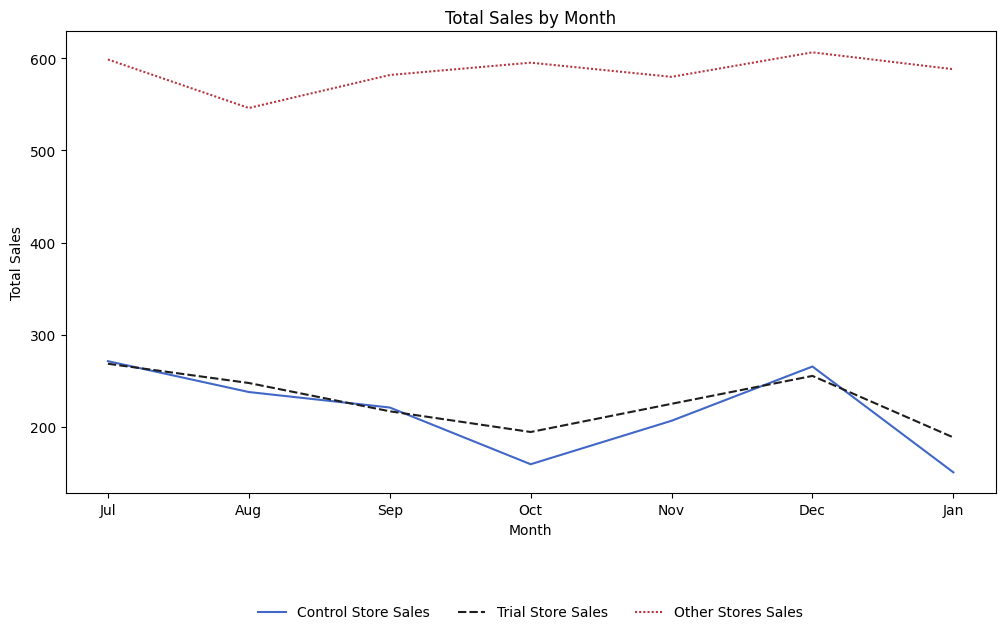

In [31]:
# Plot total Sales for all 3 types of stores


plt.figure(figsize = (12, 6))
plt.title('Total Sales by Month')
ax = sns.lineplot(data=combinePlot, palette="icefire")

plt.ylabel("Total Sales")
sns.move_legend(
    ax, "lower center",
    bbox_to_anchor=(0.5, -.3),
    ncol=3,
    frameon=False,
)

# Visual checks on customer count trends by comparing the trial store to the control store and other stores.

In [32]:
control_Customer_Plot = pastSales.loc[pastSales['store_type'] == 'Control Store', ['Month', 'no_Customers']]
control_Customer_Plot.set_index('Month', inplace = True)

trial_Customer_Plot = pastSales.loc[pastSales['store_type'] == 'Trial Store', ['Month', 'no_Customers']]
trial_Customer_Plot.set_index('Month', inplace = True)

other_Customer_Plot = pastSales.loc[pastSales['store_type'] == 'Other Stores', ['Month', 'no_Customers']]
other_Customer_Plot = pd.DataFrame(other_Customer_Plot.groupby('Month')['no_Customers'].mean())

# Renaming Column Names
control_Customer_Plot.rename(columns = {'no_Customers': 'Control Store Customers'}, inplace = True)
trial_Customer_Plot.rename(columns = {'no_Customers': 'Trial Store Customers'}, inplace = True)
other_Customer_Plot.rename(columns = {'no_Customers': 'Other Stores Customers'}, inplace = True)

# Concatenate
combine_Customer_Plot = pd.concat([control_Customer_Plot, trial_Customer_Plot, other_Customer_Plot], axis = 1)

combine_Customer_Plot

,Control Store Customers,Trial Store Customers,Other Stores Customers
Month,,,
Jul,47,47,68.447471
Aug,43,46,67.186770
Sep,40,40,66.614786
Oct,32,36,67.879377
Nov,39,39,66.696498
Dec,43,43,69.354086
Jan,31,31,67.389105


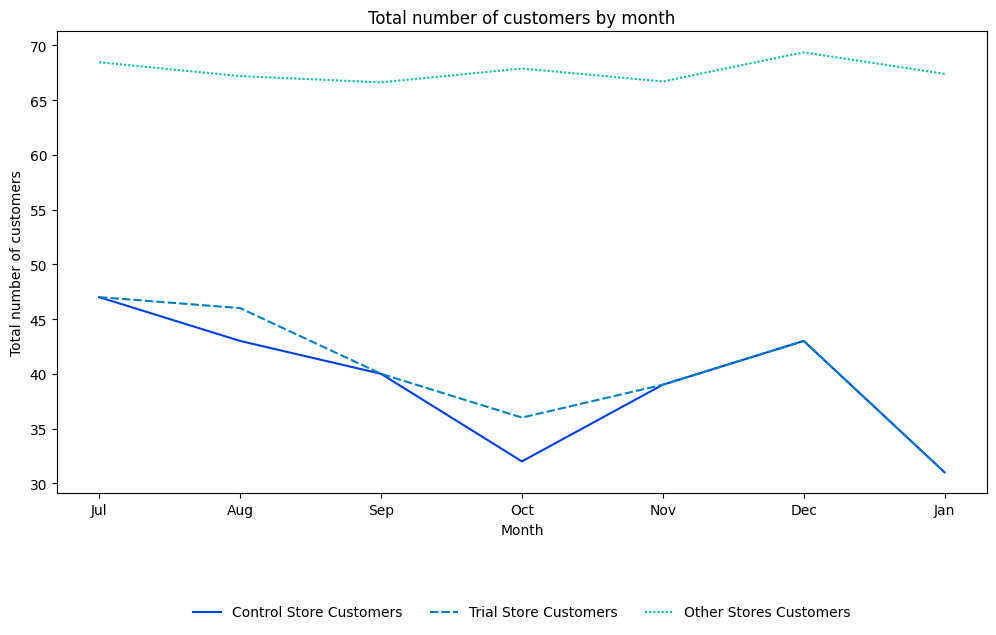

In [33]:

# Plot total number of customers for all 3 types of stores

plt.figure(figsize = (12, 6))
plt.title('Total number of customers by month')
ax1 = sns.lineplot(data=combine_Customer_Plot, palette="winter")

plt.ylabel("Total number of customers")
sns.move_legend(
    ax1, "lower center",
    bbox_to_anchor=(0.5, -.3),
    ncol=3,
    frameon=False,
)

# Assessment of trial

**The trial period goes from the start of February 2019 to April 2019. We now want to see if there has been an uplift in overall chip sales.**

In [34]:
preTrialMeasures

,STORE_NBR,YEARMONTH,Total Sales,no_Customers,trans_per_customer,chips_per_customer,average_price,store_type,TransactionMonth,Month
0,1,201807,188.9,47,1.042553,1.183673,3.256897,Other Stores,2018-07-01,Jul
1,1,201808,168.4,41,1.000000,1.268293,3.238462,Other Stores,2018-08-01,Aug
2,1,201809,268.1,57,1.035088,1.203390,3.776056,Other Stores,2018-09-01,Sep
3,1,201810,175.4,39,1.025641,1.275000,3.439216,Other Stores,2018-10-01,Oct
4,1,201811,184.8,44,1.022727,1.222222,3.360000,Other Stores,2018-11-01,Nov
...,...,...,...,...,...,...,...,...,...,...
3155,272,201809,294.5,31,1.129032,1.971429,4.268116,Other Stores,2018-09-01,Sep
3156,272,201810,405.1,41,1.146341,2.000000,4.309574,Other Stores,2018-10-01,Oct
3157,272,201811,355.8,39,1.102564,1.930233,4.286747,Other Stores,2018-11-01,Nov
3158,272,201812,363.1,43,1.000000,1.883721,4.482716,Other Stores,2018-12-01,Dec


In [35]:
# Scale pre-trial control sales to match pre-trial trial store sales

trial_sales_sum = preTrialMeasures.loc[preTrialMeasures['store_type'] == 'Trial Store' , 'Total Sales'].sum()
control_sales_sum = preTrialMeasures.loc[preTrialMeasures['store_type'] == 'Control Store' , 'Total Sales'].sum()
scalingFactorForControlSales = trial_sales_sum/ control_sales_sum
scalingFactorForControlSales

np.float64(1.0555739331789615)

In [36]:
# Apply the scaling factor

measureOverTimeSales = measureOverTime
scaledControlSales = measureOverTimeSales.loc[measureOverTimeSales['STORE_NBR'] == control_store]
scaledControlSales['controlSales'] = scaledControlSales['Total Sales'] * scalingFactorForControlSales
scaledControlSales

,STORE_NBR,YEARMONTH,Total Sales,no_Customers,trans_per_customer,chips_per_customer,average_price,controlSales
2695,233,201807,271.2,47,1.042553,1.612245,3.432911,286.271651
2696,233,201808,237.7,43,1.023256,1.522727,3.547761,250.909924
2697,233,201809,220.9,40,1.075000,1.581395,3.248529,233.176282
2698,233,201810,159.3,32,1.000000,1.500000,3.318750,168.152928
2699,233,201811,206.5,39,1.025641,1.525000,3.385246,217.976017
2700,233,201812,265.4,43,1.046512,1.555556,3.791429,280.149322
2701,233,201901,150.5,31,1.000000,1.322581,3.670732,158.863877
2702,233,201902,220.7,42,1.023810,1.488372,3.448437,232.965167
2703,233,201903,180.6,35,1.028571,1.444444,3.473077,190.636652
2704,233,201904,144.2,27,1.037037,1.464286,3.517073,152.213761


In [37]:
# Add a new column 'TransactionMonth' to 'scaledControlSales'

scaledControlSales['TransactionMonth'] = pd.to_datetime(scaledControlSales['YEARMONTH'].astype(str), format = '%Y%m')
scaledControlSales

,STORE_NBR,YEARMONTH,Total Sales,no_Customers,trans_per_customer,chips_per_customer,average_price,controlSales,TransactionMonth
2695,233,201807,271.2,47,1.042553,1.612245,3.432911,286.271651,2018-07-01
2696,233,201808,237.7,43,1.023256,1.522727,3.547761,250.909924,2018-08-01
2697,233,201809,220.9,40,1.075000,1.581395,3.248529,233.176282,2018-09-01
2698,233,201810,159.3,32,1.000000,1.500000,3.318750,168.152928,2018-10-01
2699,233,201811,206.5,39,1.025641,1.525000,3.385246,217.976017,2018-11-01
2700,233,201812,265.4,43,1.046512,1.555556,3.791429,280.149322,2018-12-01
2701,233,201901,150.5,31,1.000000,1.322581,3.670732,158.863877,2019-01-01
2702,233,201902,220.7,42,1.023810,1.488372,3.448437,232.965167,2019-02-01
2703,233,201903,180.6,35,1.028571,1.444444,3.473077,190.636652,2019-03-01
2704,233,201904,144.2,27,1.037037,1.464286,3.517073,152.213761,2019-04-01


**Now that we have comparable sales figures for the control store, we can calculate the percentage difference between the scaled control sales and the trial store's sales during the trial period.**

In [38]:
measureOverTime

,STORE_NBR,YEARMONTH,Total Sales,no_Customers,trans_per_customer,chips_per_customer,average_price
0,1,201807,188.9,47,1.042553,1.183673,3.256897
1,1,201808,168.4,41,1.000000,1.268293,3.238462
2,1,201809,268.1,57,1.035088,1.203390,3.776056
3,1,201810,175.4,39,1.025641,1.275000,3.439216
4,1,201811,184.8,44,1.022727,1.222222,3.360000
...,...,...,...,...,...,...,...
3160,272,201902,385.3,44,1.068182,1.893617,4.329213
3161,272,201903,421.9,48,1.062500,1.901961,4.349485
3162,272,201904,445.1,54,1.018519,1.909091,4.239048
3163,272,201905,314.6,34,1.176471,1.775000,4.430986


In [39]:
percentageDiff = scaledControlSales[['YEARMONTH','controlSales']]
percentageDiff.reset_index(drop = True, inplace = True)

In [40]:
trial_sales = measureOverTime.loc[measureOverTime['STORE_NBR'] == trial_store , 'Total Sales']
trial_sales.reset_index(drop = True, inplace = True)

percentageDiff = pd.concat([percentageDiff, trial_sales], axis = 1)
percentageDiff.rename(columns = {'Total Sales': 'Trial_Sales'}, inplace = True)
percentageDiff

,YEARMONTH,controlSales,Trial_Sales
0,201807,286.271651,268.4
1,201808,250.909924,247.5
2,201809,233.176282,216.8
3,201810,168.152928,194.3
4,201811,217.976017,224.9
5,201812,280.149322,255.2
6,201901,158.863877,188.4
7,201902,232.965167,211.6
8,201903,190.636652,255.1
9,201904,152.213761,258.1


In [41]:
percentageDiff['percentageDiff'] = abs(percentageDiff.controlSales - percentageDiff.Trial_Sales) / percentageDiff.controlSales
percentageDiff

,YEARMONTH,controlSales,Trial_Sales,percentageDiff
0,201807,286.271651,268.4,0.062429
1,201808,250.909924,247.5,0.013590
2,201809,233.176282,216.8,0.070231
3,201810,168.152928,194.3,0.155496
4,201811,217.976017,224.9,0.031765
5,201812,280.149322,255.2,0.089057
6,201901,158.863877,188.4,0.185921
7,201902,232.965167,211.6,0.091710
8,201903,190.636652,255.1,0.338148
9,201904,152.213761,258.1,0.695642


**As our null hypothesis is that the trial period is the same as the pre-trial period, let's take the standard deviation based on the scaled percentage difference in the pre-trial period**

In [42]:
stdDev = stdev(percentageDiff.loc[percentageDiff['YEARMONTH'] < 201902, 'percentageDiff'])
stdDev

0.0629894932288591

In [43]:
# Note that there are 8 months in the pre-trial period , Hence 8 - 1 = 7 degrees of freedom
degreesOfFreedom = 7

In [44]:
#### We will test with a null hypothesis of there being 0 difference between trial and control stores.
percentageDiff['tValue'] = (percentageDiff['percentageDiff'] - 0) / stdDev
percentageDiff.loc[(percentageDiff['YEARMONTH'] < 201905 ) & (percentageDiff['YEARMONTH'] > 201901), 'tValue']

,tValue
7,1.455952
8,5.368319
9,11.043773


In [45]:
#### Find the 95th percentile of the t distribution with the degreesOfFreedom = 7

t95 = t.isf(0.05, degreesOfFreedom)
print('95th percentile of the t distribution with the degrees Of Freedom 7   -', t95)

95th percentile of the t distribution with the degrees Of Freedom 7   - 1.8945786050613054


* *We can observe that the t-value is much larger than the 95th percentile value of the t-distribution for March and April - i.e. the increase in sales in the trial store in March and April is statistically greater than in the control store.*

In [46]:
measureOverTimeSales = measureOverTime
measureOverTimeSales

,STORE_NBR,YEARMONTH,Total Sales,no_Customers,trans_per_customer,chips_per_customer,average_price
0,1,201807,188.9,47,1.042553,1.183673,3.256897
1,1,201808,168.4,41,1.000000,1.268293,3.238462
2,1,201809,268.1,57,1.035088,1.203390,3.776056
3,1,201810,175.4,39,1.025641,1.275000,3.439216
4,1,201811,184.8,44,1.022727,1.222222,3.360000
...,...,...,...,...,...,...,...
3160,272,201902,385.3,44,1.068182,1.893617,4.329213
3161,272,201903,421.9,48,1.062500,1.901961,4.349485
3162,272,201904,445.1,54,1.018519,1.909091,4.239048
3163,272,201905,314.6,34,1.176471,1.775000,4.430986


In [47]:
measureOverTimeSales['TransactionMonth'] = pd.to_datetime(measureOverTimeSales['YEARMONTH'].astype(str), format = '%Y%m')
measureOverTimeSales

,STORE_NBR,YEARMONTH,Total Sales,no_Customers,trans_per_customer,chips_per_customer,average_price,TransactionMonth
0,1,201807,188.9,47,1.042553,1.183673,3.256897,2018-07-01
1,1,201808,168.4,41,1.000000,1.268293,3.238462,2018-08-01
2,1,201809,268.1,57,1.035088,1.203390,3.776056,2018-09-01
3,1,201810,175.4,39,1.025641,1.275000,3.439216,2018-10-01
4,1,201811,184.8,44,1.022727,1.222222,3.360000,2018-11-01
...,...,...,...,...,...,...,...,...
3160,272,201902,385.3,44,1.068182,1.893617,4.329213,2019-02-01
3161,272,201903,421.9,48,1.062500,1.901961,4.349485,2019-03-01
3162,272,201904,445.1,54,1.018519,1.909091,4.239048,2019-04-01
3163,272,201905,314.6,34,1.176471,1.775000,4.430986,2019-05-01


In [48]:
#### Trial and control store total sales

pastSales = measureOverTimeSales.loc[measureOverTimeSales['STORE_NBR'] == trial_store, ['TransactionMonth', 'Total Sales']]
pastSales.set_index('TransactionMonth', inplace = True)
pastSales.rename(columns = {'Total Sales': 'Trial Sales'}, inplace = True)
pastSales

,Trial Sales
TransactionMonth,
2018-07-01,268.4
2018-08-01,247.5
2018-09-01,216.8
2018-10-01,194.3
2018-11-01,224.9
2018-12-01,255.2
2019-01-01,188.4
2019-02-01,211.6
2019-03-01,255.1


In [49]:
#### Control store 95th percentile

controlSales = scaledControlSales.loc[:, ['TransactionMonth', 'controlSales']]
controlSales.set_index('TransactionMonth', inplace = True)
controlSales.rename(columns = {'controlSales': 'Control Sales'}, inplace = True)
controlSales

,Control Sales
TransactionMonth,
2018-07-01,286.271651
2018-08-01,250.909924
2018-09-01,233.176282
2018-10-01,168.152928
2018-11-01,217.976017
2018-12-01,280.149322
2019-01-01,158.863877
2019-02-01,232.965167
2019-03-01,190.636652


In [50]:
#### Control store 95th percentile
controlSales['Control store 95th percentile'] = controlSales['Control Sales'] * (1 + stdDev*2)

#### Control store 5th percentile

controlSales['Control store 5th percentile'] = controlSales['Control Sales'] * (1 - stdDev*2)

controlSales

,Control Sales,Control store 95th percentile,Control store 5th percentile
TransactionMonth,,,
2018-07-01,286.271651,322.335863,250.207438
2018-08-01,250.909924,282.519302,219.300546
2018-09-01,233.176282,262.551593,203.800970
2018-10-01,168.152928,189.336663,146.969192
2018-11-01,217.976017,245.436415,190.515619
2018-12-01,280.149322,315.442249,244.856394
2019-01-01,158.863877,178.877387,138.850367
2019-02-01,232.965167,262.313883,203.616451
2019-03-01,190.636652,214.652865,166.620440


In [51]:
trialAssessment = pd.merge(controlSales, pastSales, left_index = True, right_index = True)
trialAssessment

,Control Sales,Control store 95th percentile,Control store 5th percentile,Trial Sales
TransactionMonth,,,,
2018-07-01,286.271651,322.335863,250.207438,268.4
2018-08-01,250.909924,282.519302,219.300546,247.5
2018-09-01,233.176282,262.551593,203.800970,216.8
2018-10-01,168.152928,189.336663,146.969192,194.3
2018-11-01,217.976017,245.436415,190.515619,224.9
2018-12-01,280.149322,315.442249,244.856394,255.2
2019-01-01,158.863877,178.877387,138.850367,188.4
2019-02-01,232.965167,262.313883,203.616451,211.6
2019-03-01,190.636652,214.652865,166.620440,255.1


* *Let’s create a more visual version of this by plotting the sales of the control store, the sales of the trial stores and the 95th percentile value of sales of the control store.*

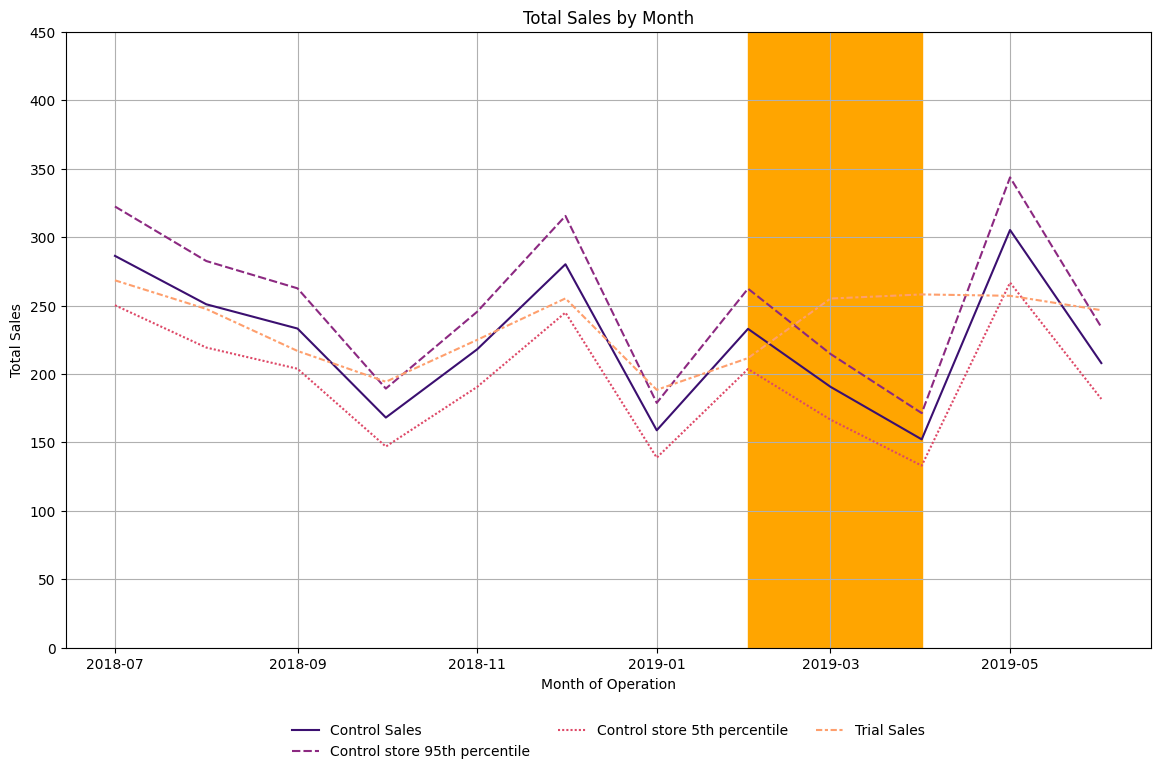

In [52]:
plt.figure(figsize = (14,8))
ax2 = sns.lineplot(data=trialAssessment, palette = 'magma')

sns.move_legend(
    ax2, "lower center",
    bbox_to_anchor=(0.5, -.2),
    ncol=3,
    frameon=False,
)

plt.title('Total Sales by Month')
plt.xlabel('Month of Operation')
plt.ylabel('Total Sales')
plt.ylim((0, 450))


plt.axvspan(*mdates.datestr2num(['2019-02-01', '2019-04-01']), color = 'orange', alpha = 1)
plt.grid()

**The trial period is highlighted by the orange strip**

*The results show that the trial in store 77 is significantly different to its control store in the trial period as the trial store performance lies outside the 5% to 95% confidence interval of the control store in two of the three trial months.*

# Let's have a look at assessing this for number of customers as well.

In [53]:
trial_customers = preTrialMeasures.loc[preTrialMeasures['store_type'] == 'Trial Store' , 'no_Customers'].sum()
control_customers = preTrialMeasures.loc[preTrialMeasures['store_type'] == 'Control Store', 'no_Customers'].sum()
scalingFactorForControlCust = trial_customers / control_customers
scalingFactorForControlCust

np.float64(1.0254545454545454)

In [54]:
measureOverTimeCusts = measureOverTime
measureOverTimeCusts

,STORE_NBR,YEARMONTH,Total Sales,no_Customers,trans_per_customer,chips_per_customer,average_price,TransactionMonth
0,1,201807,188.9,47,1.042553,1.183673,3.256897,2018-07-01
1,1,201808,168.4,41,1.000000,1.268293,3.238462,2018-08-01
2,1,201809,268.1,57,1.035088,1.203390,3.776056,2018-09-01
3,1,201810,175.4,39,1.025641,1.275000,3.439216,2018-10-01
4,1,201811,184.8,44,1.022727,1.222222,3.360000,2018-11-01
...,...,...,...,...,...,...,...,...
3160,272,201902,385.3,44,1.068182,1.893617,4.329213,2019-02-01
3161,272,201903,421.9,48,1.062500,1.901961,4.349485,2019-03-01
3162,272,201904,445.1,54,1.018519,1.909091,4.239048,2019-04-01
3163,272,201905,314.6,34,1.176471,1.775000,4.430986,2019-05-01


In [55]:
scaledControlCustomers = measureOverTimeCusts.loc[measureOverTimeCusts['STORE_NBR'] == control_store]
scaledControlCustomers

,STORE_NBR,YEARMONTH,Total Sales,no_Customers,trans_per_customer,chips_per_customer,average_price,TransactionMonth
2695,233,201807,271.2,47,1.042553,1.612245,3.432911,2018-07-01
2696,233,201808,237.7,43,1.023256,1.522727,3.547761,2018-08-01
2697,233,201809,220.9,40,1.075000,1.581395,3.248529,2018-09-01
2698,233,201810,159.3,32,1.000000,1.500000,3.318750,2018-10-01
2699,233,201811,206.5,39,1.025641,1.525000,3.385246,2018-11-01
2700,233,201812,265.4,43,1.046512,1.555556,3.791429,2018-12-01
2701,233,201901,150.5,31,1.000000,1.322581,3.670732,2019-01-01
2702,233,201902,220.7,42,1.023810,1.488372,3.448437,2019-02-01
2703,233,201903,180.6,35,1.028571,1.444444,3.473077,2019-03-01
2704,233,201904,144.2,27,1.037037,1.464286,3.517073,2019-04-01


In [56]:
scaledControlCustomers['Control_Customers'] = scaledControlCustomers['no_Customers'] * scalingFactorForControlCust
scaledControlCustomers

,STORE_NBR,YEARMONTH,Total Sales,no_Customers,trans_per_customer,chips_per_customer,average_price,TransactionMonth,Control_Customers
2695,233,201807,271.2,47,1.042553,1.612245,3.432911,2018-07-01,48.196364
2696,233,201808,237.7,43,1.023256,1.522727,3.547761,2018-08-01,44.094545
2697,233,201809,220.9,40,1.075000,1.581395,3.248529,2018-09-01,41.018182
2698,233,201810,159.3,32,1.000000,1.500000,3.318750,2018-10-01,32.814545
2699,233,201811,206.5,39,1.025641,1.525000,3.385246,2018-11-01,39.992727
2700,233,201812,265.4,43,1.046512,1.555556,3.791429,2018-12-01,44.094545
2701,233,201901,150.5,31,1.000000,1.322581,3.670732,2019-01-01,31.789091
2702,233,201902,220.7,42,1.023810,1.488372,3.448437,2019-02-01,43.069091
2703,233,201903,180.6,35,1.028571,1.444444,3.473077,2019-03-01,35.890909
2704,233,201904,144.2,27,1.037037,1.464286,3.517073,2019-04-01,27.687273


In [57]:
# Calculate the percentage difference between scaled control customers. and trial customers.

percentageDiff = scaledControlCustomers[['YEARMONTH','Control_Customers']]
percentageDiff.reset_index(drop = True, inplace = True)
percentageDiff

,YEARMONTH,Control_Customers
0,201807,48.196364
1,201808,44.094545
2,201809,41.018182
3,201810,32.814545
4,201811,39.992727
5,201812,44.094545
6,201901,31.789091
7,201902,43.069091
8,201903,35.890909
9,201904,27.687273


In [58]:
trial_Customers = measureOverTimeCusts.loc[measureOverTimeCusts['STORE_NBR'] == trial_store, 'no_Customers']
trial_Customers.reset_index(drop = True, inplace = True)
trial_Customers

,no_Customers
0,47
1,46
2,40
3,36
4,39
5,43
6,31
7,40
8,46
9,47


In [59]:
percentageDiff = pd.concat([percentageDiff, trial_Customers], axis = 1)
percentageDiff.rename(columns = {'no_Customers': 'Trial_Customers'}, inplace = True)
percentageDiff

,YEARMONTH,Control_Customers,Trial_Customers
0,201807,48.196364,47
1,201808,44.094545,46
2,201809,41.018182,40
3,201810,32.814545,36
4,201811,39.992727,39
5,201812,44.094545,43
6,201901,31.789091,31
7,201902,43.069091,40
8,201903,35.890909,46
9,201904,27.687273,47


In [60]:
percentageDiff['percentageDiff'] = abs(percentageDiff.Control_Customers - percentageDiff.Trial_Customers) / percentageDiff.Control_Customers
percentageDiff

,YEARMONTH,Control_Customers,Trial_Customers,percentageDiff
0,201807,48.196364,47,0.024823
1,201808,44.094545,46,0.043213
2,201809,41.018182,40,0.024823
3,201810,32.814545,36,0.097074
4,201811,39.992727,39,0.024823
5,201812,44.094545,43,0.024823
6,201901,31.789091,31,0.024823
7,201902,43.069091,40,0.071260
8,201903,35.890909,46,0.281662
9,201904,27.687273,47,0.697531


**Let’s again see if the difference is significant visually!**

In [61]:
stdDev = stdev(percentageDiff.loc[percentageDiff['YEARMONTH'] < 201902, 'percentageDiff'])

degreesOfFreedom = 7

**As our null hypothesis is that the trial period is the same as the pre‐trial period, let's take the standard deviation based on the scaledpercentage difference in the pre‐trial period**

In [62]:
percentageDiff['T_value'] = (percentageDiff['percentageDiff'] - 0) / stdDev
percentageDiff.loc[(percentageDiff['YEARMONTH'] > 201901) & (percentageDiff['YEARMONTH'] < 201905), 'T_value']

,T_value
7,2.635994
8,10.419045
9,25.802615


In [63]:
#### 95th percentile of the t distribution with degreesOfFreedom = 7

t95 = t.isf(0.05, degreesOfFreedom)
print('95th percentile of the t distribution with the degrees Of Freedom 7   -', t95)

95th percentile of the t distribution with the degrees Of Freedom 7   - 1.8945786050613054


*We Can see that the t-value is much greater than the 95th percentile of the t distribution*

In [64]:
controlCustomers = scaledControlCustomers.loc[:, ['TransactionMonth', 'Control_Customers']]
controlCustomers.set_index('TransactionMonth', inplace = True)
controlCustomers

,Control_Customers
TransactionMonth,
2018-07-01,48.196364
2018-08-01,44.094545
2018-09-01,41.018182
2018-10-01,32.814545
2018-11-01,39.992727
2018-12-01,44.094545
2019-01-01,31.789091
2019-02-01,43.069091
2019-03-01,35.890909


In [65]:
trialCustomers = measureOverTimeCusts.loc[measureOverTimeCusts['STORE_NBR'] == trial_store, ['TransactionMonth', 'no_Customers']]
trialCustomers.set_index('TransactionMonth', inplace = True)
trialCustomers.rename(columns = {'no_Customers': 'Trial Customers'}, inplace = True)
trialCustomers

,Trial Customers
TransactionMonth,
2018-07-01,47
2018-08-01,46
2018-09-01,40
2018-10-01,36
2018-11-01,39
2018-12-01,43
2019-01-01,31
2019-02-01,40
2019-03-01,46


In [66]:
#### Control store 95th percentile
controlCustomers['Control 95th % confidence Interval'] = controlCustomers['Control_Customers'] * (1 + stdDev*2)
controlCustomers['Control 5th % confidence Interval'] = controlCustomers['Control_Customers'] * (1 - stdDev*2)

# Merge trial store as well to the control store dataframe.
trial_77_Customer_Assessment = pd.merge(controlCustomers, trialCustomers, left_index = True, right_index = True)

In [67]:
trial_77_Customer_Assessment

,Control_Customers,Control 95th % confidence Interval,Control 5th % confidence Interval,Trial Customers
TransactionMonth,,,,
2018-07-01,48.196364,50.802181,45.590546,47
2018-08-01,44.094545,46.478591,41.710500,46
2018-09-01,41.018182,43.235899,38.800465,40
2018-10-01,32.814545,34.588719,31.040372,36
2018-11-01,39.992727,42.155001,37.830453,39
2018-12-01,44.094545,46.478591,41.710500,43
2019-01-01,31.789091,33.507822,30.070360,31
2019-02-01,43.069091,45.397694,40.740488,40
2019-03-01,35.890909,37.831411,33.950407,46


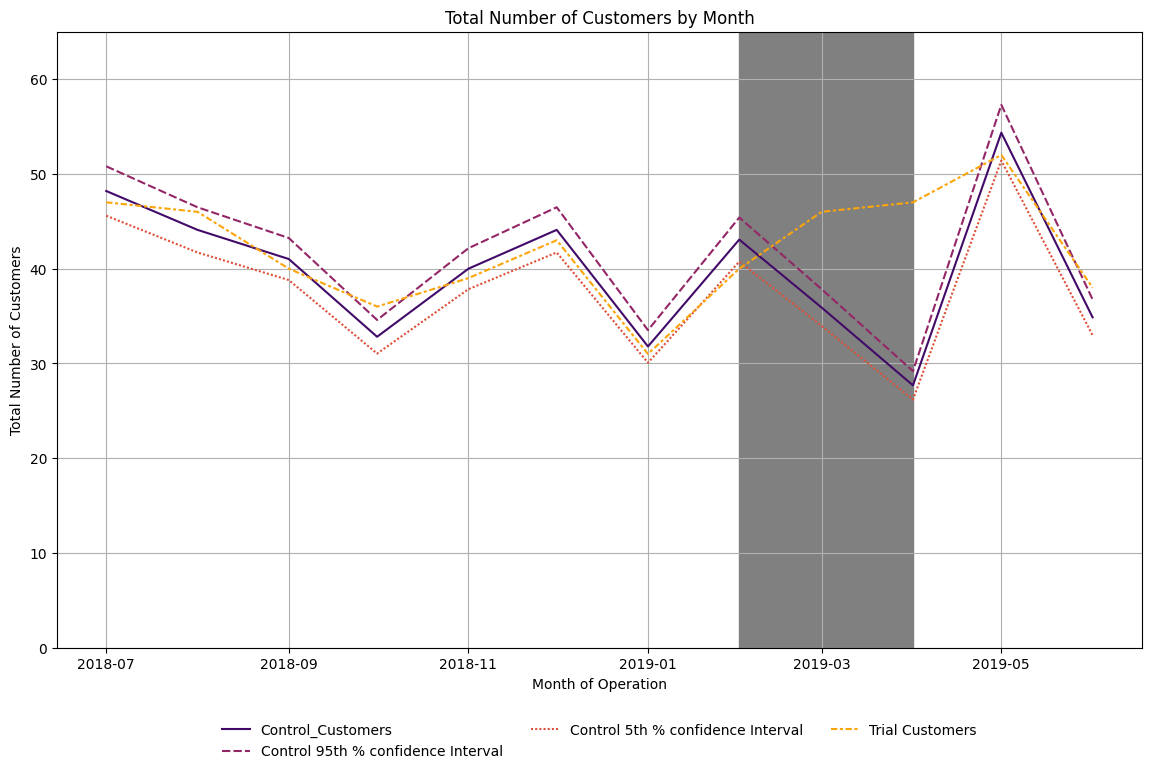

In [68]:
plt.figure(figsize = (14,8))
ax3 = sns.lineplot(data=trial_77_Customer_Assessment, palette = 'inferno')

sns.move_legend(
    ax3, "lower center",
    bbox_to_anchor=(0.5, -.2),
    ncol=3,
    frameon=False,
)

plt.title('Total Number of Customers by Month')
plt.xlabel('Month of Operation')
plt.ylabel('Total Number of Customers')
plt.ylim((0, 65))


plt.axvspan(*mdates.datestr2num(['2019-02-01', '2019-04-01']), color = 'grey', alpha = 1)
plt.grid()

# **Let’s repeat finding the control store and assessing the impact of the trial for each of the other two trial stores.**

**Trial store 86**

In [69]:
trial_store = 86

corr_Sales = calculateCorrelation(preTrialMeasures, 'Total Sales', trial_store)
corr_Customers = calculateCorrelation(preTrialMeasures, 'no_Customers', trial_store)

# Compute magnitude with trial store 86
magnitude_Sales = calculateMagnitudeDistance(preTrialMeasures, 'Total Sales', trial_store)
magnitude_Customers = calculateMagnitudeDistance(preTrialMeasures, 'no_Customers', trial_store)

In [70]:
score_Sales = pd.concat([corr_Sales, magnitude_Sales['Magnitude']], axis = 1)
score_Sales

,Store1,Store2,corr_measure,Magnitude
0,86,1,0.364734,0.488503
1,86,2,-0.055143,0.342482
2,86,3,0.139789,0.505470
3,86,4,0.073252,0.568619
4,86,5,0.502232,0.550371
...,...,...,...,...
254,86,268,-0.065090,0.319024
255,86,269,0.827575,0.617188
256,86,270,-0.661996,0.458570
257,86,271,0.557894,0.603926


In [71]:
score_Customers = pd.concat([corr_Customers, magnitude_Customers['Magnitude']], axis = 1)

In [72]:
# Add an additional column which calculates the weighted average

corr_weight = 0.5
score_Sales['scoreSales'] = corr_weight * score_Sales['corr_measure'] + (1 - corr_weight) * score_Sales['Magnitude']
score_Customers['scoreCustomers'] = corr_weight * score_Customers['corr_measure'] + (1 - corr_weight) * score_Customers['Magnitude']

In [73]:
score_Sales.set_index(['Store1', 'Store2'], inplace = True)
score_Customers.set_index(['Store1', 'Store2'], inplace = True)

score_Control = pd.concat([score_Sales['scoreSales'], score_Customers['scoreCustomers']], axis = 1)
score_Control

scoreSales  scoreCustomers
Store1 Store2                            
86     1         0.426618        0.484115
       2         0.143670        0.191026
       3         0.322630        0.256380
       4         0.320936        0.294711
       5         0.526302        0.380514
...                   ...             ...
       268       0.126967        0.358389
       269       0.722381        0.525663
       270      -0.101713       -0.070960
       271       0.580910        0.357723
       272       0.530567        0.079664

[259 rows x 2 columns]

In [74]:
# Add a new column 'finalControlScore' to 'score_Control'.

score_Control['finalControlScore'] = 0.5 * (score_Control['scoreSales'] + score_Control['scoreCustomers'])

score_Control

scoreSales  scoreCustomers  finalControlScore
Store1 Store2                                               
86     1         0.426618        0.484115           0.455367
       2         0.143670        0.191026           0.167348
       3         0.322630        0.256380           0.289505
       4         0.320936        0.294711           0.307824
       5         0.526302        0.380514           0.453408
...                   ...             ...                ...
       268       0.126967        0.358389           0.242678
       269       0.722381        0.525663           0.624022
       270      -0.101713       -0.070960          -0.086337
       271       0.580910        0.357723           0.469316
       272       0.530567        0.079664           0.305115

[259 rows x 3 columns]

In [75]:
score_Control.sort_values(by = 'finalControlScore', ascending = False).head()

scoreSales  scoreCustomers  finalControlScore
Store1 Store2                                               
86     155       0.772382        0.636309           0.704346
       114       0.717896        0.668594           0.693245
       181       0.689386        0.615839           0.652613
       138       0.708673        0.586314           0.647493
       56        0.619120        0.667115           0.643118

*For Trial Store 86, control store is 155.*

In [76]:
control_store = 155
pastSales = preTrialMeasures

store_type = []

for i in pastSales['STORE_NBR']:
    if i == trial_store:
        store_type.append('Trial Store')
    elif i == control_store:
        store_type.append('Control Store')
    else:
        store_type.append('Other Stores')

pastSales['store_type'] = store_type
pastSales.head()

,STORE_NBR,YEARMONTH,Total Sales,no_Customers,trans_per_customer,chips_per_customer,average_price,store_type,TransactionMonth,Month
0,1,201807,188.9,47,1.042553,1.183673,3.256897,Other Stores,2018-07-01,Jul
1,1,201808,168.4,41,1.000000,1.268293,3.238462,Other Stores,2018-08-01,Aug
2,1,201809,268.1,57,1.035088,1.203390,3.776056,Other Stores,2018-09-01,Sep
3,1,201810,175.4,39,1.025641,1.275000,3.439216,Other Stores,2018-10-01,Oct
4,1,201811,184.8,44,1.022727,1.222222,3.360000,Other Stores,2018-11-01,Nov


In [77]:
controlPlot = pastSales.loc[pastSales['store_type'] == 'Control Store', ['Month', 'Total Sales']]
controlPlot.set_index('Month', inplace = True)

trialPlot = pastSales.loc[pastSales['store_type'] == 'Trial Store', ['Month', 'Total Sales']]
trialPlot.set_index('Month', inplace = True)

otherPlot = pastSales.loc[pastSales['store_type'] == 'Other Stores', ['Month', 'Total Sales']]
otherPlot = pd.DataFrame(otherPlot.groupby('Month')['Total Sales'].mean())

# Renaming Column Names
controlPlot.rename(columns = {'Total Sales': 'Control Store Sales'}, inplace = True)
trialPlot.rename(columns = {'Total Sales': 'Trial Store Sales'}, inplace = True)
otherPlot.rename(columns = {'Total Sales': 'Other Stores Sales'}, inplace = True)

# Concatenate
combinePlot = pd.concat([controlPlot, trialPlot, otherPlot], axis = 1)

combinePlot

,Control Store Sales,Trial Store Sales,Other Stores Sales
Month,,,
Jul,900.6,851.00,594.054475
Aug,723.7,726.85,542.299416
Sep,939.6,855.00,576.619844
Oct,914.0,898.80,589.608560
Nov,835.0,851.20,575.016732
Dec,799.8,812.20,602.253307
Jan,834.6,800.60,583.140467


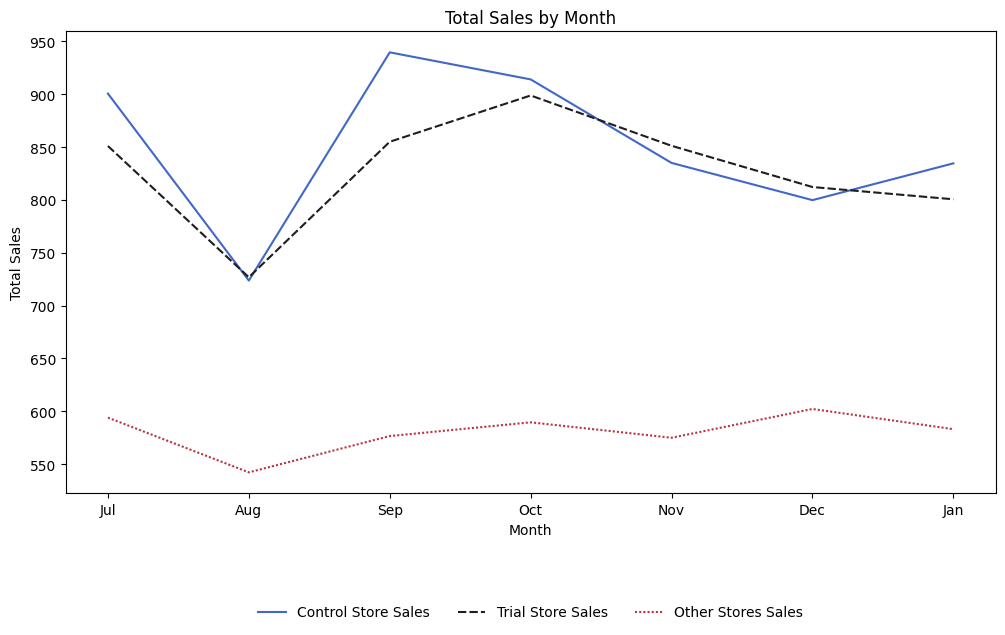

In [78]:
# Plot total Sales for all 3 types of stores


plt.figure(figsize = (12, 6))
plt.title('Total Sales by Month')
ax = sns.lineplot(data=combinePlot, palette="icefire")

plt.ylabel("Total Sales")
sns.move_legend(
    ax, "lower center",
    bbox_to_anchor=(0.5, -.3),
    ncol=3,
    frameon=False,
)

# Visual checks on customer count trends by comparing the trial store to the control store and other stores.

In [79]:
control_Customer_Plot = pastSales.loc[pastSales['store_type'] == 'Control Store', ['Month', 'no_Customers']]
control_Customer_Plot.set_index('Month', inplace = True)

trial_Customer_Plot = pastSales.loc[pastSales['store_type'] == 'Trial Store', ['Month', 'no_Customers']]
trial_Customer_Plot.set_index('Month', inplace = True)

other_Customer_Plot = pastSales.loc[pastSales['store_type'] == 'Other Stores', ['Month', 'no_Customers']]
other_Customer_Plot = pd.DataFrame(other_Customer_Plot.groupby('Month')['no_Customers'].mean())

# Renaming Column Names
control_Customer_Plot.rename(columns = {'no_Customers': 'Control Store Customers'}, inplace = True)
trial_Customer_Plot.rename(columns = {'no_Customers': 'Trial Store Customers'}, inplace = True)
other_Customer_Plot.rename(columns = {'no_Customers': 'Other Stores Customers'}, inplace = True)

# Concatenate
combine_Customer_Plot = pd.concat([control_Customer_Plot, trial_Customer_Plot, other_Customer_Plot], axis = 1)

combine_Customer_Plot

,Control Store Customers,Trial Store Customers,Other Stores Customers
Month,,,
Jul,98,94,68.066148
Aug,87,92,66.836576
Sep,96,100,66.163424
Oct,105,105,67.326848
Nov,96,95,66.256809
Dec,91,93,68.972763
Jan,92,89,66.926070


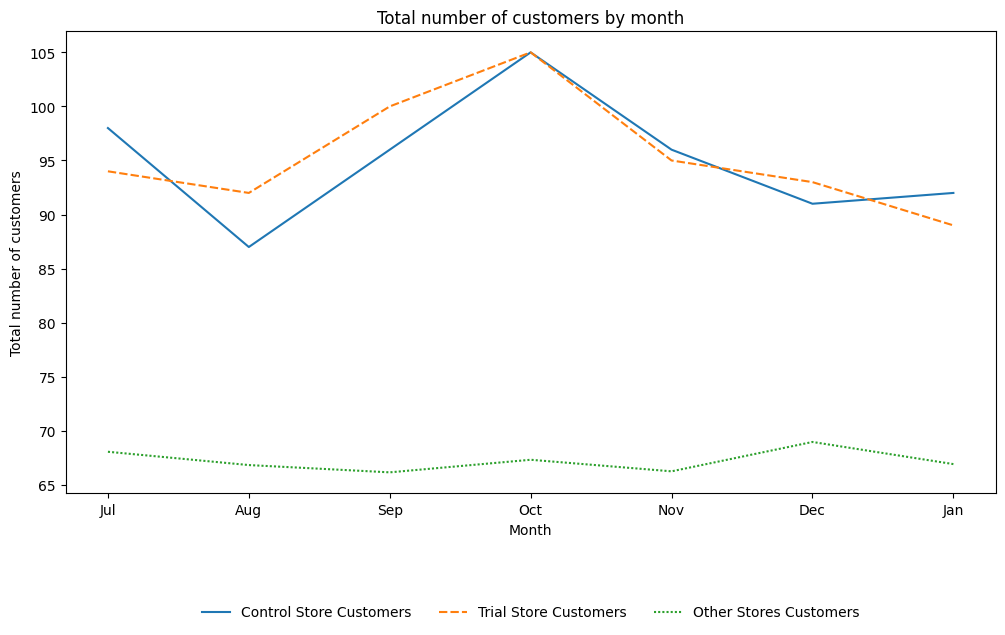

In [80]:
# Plot total number of customers for all 3 types of stores

plt.figure(figsize = (12, 6))
plt.title('Total number of customers by month')
ax1 = sns.lineplot(data=combine_Customer_Plot)

plt.ylabel("Total number of customers")
sns.move_legend(
    ax1, "lower center",
    bbox_to_anchor=(0.5, -.3),
    ncol=3,
    frameon=False,
)

**Assessment of trial**

**The trial period goes from the start of February 2019 to April 2019. We now want to see if there has been an uplift in overall chip sales.**

In [81]:
# Scale pre-trial control sales to match pre-trial trial store sales

trial_sales_sum = preTrialMeasures.loc[preTrialMeasures['store_type'] == 'Trial Store' , 'Total Sales'].sum()
control_sales_sum = preTrialMeasures.loc[preTrialMeasures['store_type'] == 'Control Store' , 'Total Sales'].sum()
scalingFactorForControlSales = trial_sales_sum/ control_sales_sum
scalingFactorForControlSales

np.float64(0.9745010340826928)

In [82]:
# Apply the scaling factor

measureOverTimeSales = measureOverTime
scaledControlSales = measureOverTimeSales.loc[measureOverTimeSales['STORE_NBR'] == control_store]
scaledControlSales['controlSales'] = scaledControlSales['Total Sales'] * scalingFactorForControlSales
scaledControlSales

,STORE_NBR,YEARMONTH,Total Sales,no_Customers,trans_per_customer,chips_per_customer,average_price,TransactionMonth,controlSales
1792,155,201807,900.60,98,1.214286,2.016807,3.752500,2018-07-01,877.635631
1793,155,201808,723.70,87,1.287356,1.883929,3.429858,2018-08-01,705.246398
1794,155,201809,939.60,96,1.354167,2.015385,3.586260,2018-09-01,915.641172
1795,155,201810,914.00,105,1.219048,2.000000,3.570312,2018-10-01,890.693945
1796,155,201811,835.00,96,1.270833,2.032787,3.366935,2018-11-01,813.708363
1797,155,201812,799.80,91,1.230769,2.017857,3.538938,2018-12-01,779.405927
1798,155,201901,834.60,92,1.271739,2.017094,3.536441,2019-01-01,813.318563
1799,155,201902,850.80,92,1.271739,2.034188,3.574790,2019-02-01,829.105480
1800,155,201903,767.00,91,1.208791,2.036364,3.424107,2019-03-01,747.442293
1801,155,201904,800.40,93,1.215054,2.017699,3.510526,2019-04-01,779.990628


**Now that we have comparable sales figures for the control store, we can calculate the percentage difference between the scaled control sales and the trial store's sales during the trial period.**

In [83]:
percentageDiff = scaledControlSales[['YEARMONTH','controlSales']]
percentageDiff.reset_index(drop = True, inplace = True)

In [84]:
trial_sales = measureOverTime.loc[measureOverTime['STORE_NBR'] == trial_store , 'Total Sales']
trial_sales.reset_index(drop = True, inplace = True)

percentageDiff = pd.concat([percentageDiff, trial_sales], axis = 1)
percentageDiff.rename(columns = {'Total Sales': 'Trial_Sales'}, inplace = True)
percentageDiff

,YEARMONTH,controlSales,Trial_Sales
0,201807,877.635631,851.00
1,201808,705.246398,726.85
2,201809,915.641172,855.00
3,201810,890.693945,898.80
4,201811,813.708363,851.20
5,201812,779.405927,812.20
6,201901,813.318563,800.60
7,201902,829.105480,872.80
8,201903,747.442293,945.40
9,201904,779.990628,804.00


In [85]:
percentageDiff['percentageDiff'] = abs(percentageDiff.controlSales - percentageDiff.Trial_Sales) / percentageDiff.controlSales
percentageDiff

,YEARMONTH,controlSales,Trial_Sales,percentageDiff
0,201807,877.635631,851.00,0.030349
1,201808,705.246398,726.85,0.030633
2,201809,915.641172,855.00,0.066228
3,201810,890.693945,898.80,0.009101
4,201811,813.708363,851.20,0.046075
5,201812,779.405927,812.20,0.042076
6,201901,813.318563,800.60,0.015638
7,201902,829.105480,872.80,0.052701
8,201903,747.442293,945.40,0.264847
9,201904,779.990628,804.00,0.030782


**As our null hypothesis is that the trial period is the same as the pre-trial period, let's take the standard deviation based on the scaled percentage difference in the pre-trial period**

In [86]:
stdDev = stdev(percentageDiff.loc[percentageDiff['YEARMONTH'] < 201902, 'percentageDiff'])
stdDev

0.019282320188439537

In [87]:
# Note that there are 8 months in the pre-trial period , Hence 8 - 1 = 7 degrees of freedom
degreesOfFreedom = 7

In [88]:
measureOverTimeSales = measureOverTime
measureOverTimeSales

,STORE_NBR,YEARMONTH,Total Sales,no_Customers,trans_per_customer,chips_per_customer,average_price,TransactionMonth
0,1,201807,188.9,47,1.042553,1.183673,3.256897,2018-07-01
1,1,201808,168.4,41,1.000000,1.268293,3.238462,2018-08-01
2,1,201809,268.1,57,1.035088,1.203390,3.776056,2018-09-01
3,1,201810,175.4,39,1.025641,1.275000,3.439216,2018-10-01
4,1,201811,184.8,44,1.022727,1.222222,3.360000,2018-11-01
...,...,...,...,...,...,...,...,...
3160,272,201902,385.3,44,1.068182,1.893617,4.329213,2019-02-01
3161,272,201903,421.9,48,1.062500,1.901961,4.349485,2019-03-01
3162,272,201904,445.1,54,1.018519,1.909091,4.239048,2019-04-01
3163,272,201905,314.6,34,1.176471,1.775000,4.430986,2019-05-01


In [89]:
#### Trial and control store total sales

pastSales = measureOverTimeSales.loc[measureOverTimeSales['STORE_NBR'] == trial_store, ['TransactionMonth', 'Total Sales']]
pastSales.set_index('TransactionMonth', inplace = True)
pastSales.rename(columns = {'Total Sales': 'Trial Sales'}, inplace = True)
pastSales

,Trial Sales
TransactionMonth,
2018-07-01,851.00
2018-08-01,726.85
2018-09-01,855.00
2018-10-01,898.80
2018-11-01,851.20
2018-12-01,812.20
2019-01-01,800.60
2019-02-01,872.80
2019-03-01,945.40


In [90]:
#### Control store 95th percentile

controlSales = scaledControlSales.loc[:, ['TransactionMonth', 'controlSales']]
controlSales.set_index('TransactionMonth', inplace = True)
controlSales.rename(columns = {'controlSales': 'Control Sales'}, inplace = True)
controlSales

,Control Sales
TransactionMonth,
2018-07-01,877.635631
2018-08-01,705.246398
2018-09-01,915.641172
2018-10-01,890.693945
2018-11-01,813.708363
2018-12-01,779.405927
2019-01-01,813.318563
2019-02-01,829.105480
2019-03-01,747.442293


In [91]:
#### Control store 95th percentile
controlSales['Control store 95th percentile'] = controlSales['Control Sales'] * (1 + stdDev*2)

#### Control store 5th percentile

controlSales['Control store 5th percentile'] = controlSales['Control Sales'] * (1 - stdDev*2)

controlSales

,Control Sales,Control store 95th percentile,Control store 5th percentile
TransactionMonth,,,
2018-07-01,877.635631,911.481334,843.789929
2018-08-01,705.246398,732.443972,678.048825
2018-09-01,915.641172,950.952544,880.329799
2018-10-01,890.693945,925.043237,856.344653
2018-11-01,813.708363,845.088734,782.327993
2018-12-01,779.405927,809.463436,749.348418
2019-01-01,813.318563,844.683901,781.953225
2019-02-01,829.105480,861.079634,797.131325
2019-03-01,747.442293,776.267136,718.617450


In [92]:
trialAssessment = pd.merge(controlSales, pastSales, left_index = True, right_index = True)
trialAssessment

,Control Sales,Control store 95th percentile,Control store 5th percentile,Trial Sales
TransactionMonth,,,,
2018-07-01,877.635631,911.481334,843.789929,851.00
2018-08-01,705.246398,732.443972,678.048825,726.85
2018-09-01,915.641172,950.952544,880.329799,855.00
2018-10-01,890.693945,925.043237,856.344653,898.80
2018-11-01,813.708363,845.088734,782.327993,851.20
2018-12-01,779.405927,809.463436,749.348418,812.20
2019-01-01,813.318563,844.683901,781.953225,800.60
2019-02-01,829.105480,861.079634,797.131325,872.80
2019-03-01,747.442293,776.267136,718.617450,945.40


* *Let’s create a more visual version of this by plotting the sales of the control store, the sales of the trial stores and the 95th percentile value of sales of the control store.*

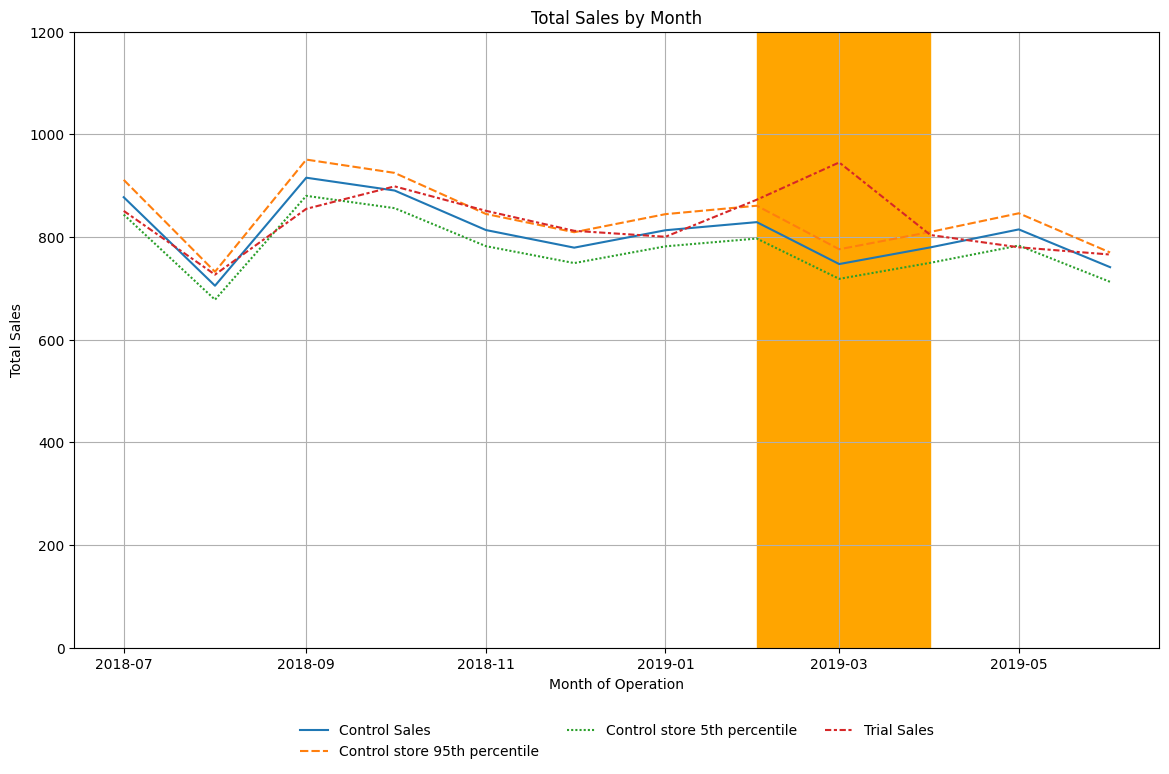

In [93]:
plt.figure(figsize = (14,8))
ax2 = sns.lineplot(data=trialAssessment)

sns.move_legend(
    ax2, "lower center",
    bbox_to_anchor=(0.5, -.2),
    ncol=3,
    frameon=False,
)

plt.title('Total Sales by Month')
plt.xlabel('Month of Operation')
plt.ylabel('Total Sales')
plt.ylim((0, 1200))


plt.axvspan(*mdates.datestr2num(['2019-02-01', '2019-04-01']), color = 'orange', alpha = 1)
plt.grid()

**The trial period is highlighted by the orange strip.**

*The results show that the trial in store 86 is significantly different to its control store in the trial period as the trial store performance lies outside the 5% to 95% confidence interval of the control store in two of the three trial months.*

**Let's have a look at assessing this for number of customers as well.**

In [94]:
trial_customers = preTrialMeasures.loc[preTrialMeasures['store_type'] == 'Trial Store' , 'no_Customers'].sum()
control_customers = preTrialMeasures.loc[preTrialMeasures['store_type'] == 'Control Store', 'no_Customers'].sum()
scalingFactorForControlCust = trial_customers / control_customers
scalingFactorForControlCust

np.float64(1.0045112781954888)

In [95]:
measureOverTimeCusts = measureOverTime
measureOverTimeCusts

,STORE_NBR,YEARMONTH,Total Sales,no_Customers,trans_per_customer,chips_per_customer,average_price,TransactionMonth
0,1,201807,188.9,47,1.042553,1.183673,3.256897,2018-07-01
1,1,201808,168.4,41,1.000000,1.268293,3.238462,2018-08-01
2,1,201809,268.1,57,1.035088,1.203390,3.776056,2018-09-01
3,1,201810,175.4,39,1.025641,1.275000,3.439216,2018-10-01
4,1,201811,184.8,44,1.022727,1.222222,3.360000,2018-11-01
...,...,...,...,...,...,...,...,...
3160,272,201902,385.3,44,1.068182,1.893617,4.329213,2019-02-01
3161,272,201903,421.9,48,1.062500,1.901961,4.349485,2019-03-01
3162,272,201904,445.1,54,1.018519,1.909091,4.239048,2019-04-01
3163,272,201905,314.6,34,1.176471,1.775000,4.430986,2019-05-01


In [96]:
scaledControlCustomers = measureOverTimeCusts.loc[measureOverTimeCusts['STORE_NBR'] == control_store]
scaledControlCustomers

,STORE_NBR,YEARMONTH,Total Sales,no_Customers,trans_per_customer,chips_per_customer,average_price,TransactionMonth
1792,155,201807,900.60,98,1.214286,2.016807,3.752500,2018-07-01
1793,155,201808,723.70,87,1.287356,1.883929,3.429858,2018-08-01
1794,155,201809,939.60,96,1.354167,2.015385,3.586260,2018-09-01
1795,155,201810,914.00,105,1.219048,2.000000,3.570312,2018-10-01
1796,155,201811,835.00,96,1.270833,2.032787,3.366935,2018-11-01
1797,155,201812,799.80,91,1.230769,2.017857,3.538938,2018-12-01
1798,155,201901,834.60,92,1.271739,2.017094,3.536441,2019-01-01
1799,155,201902,850.80,92,1.271739,2.034188,3.574790,2019-02-01
1800,155,201903,767.00,91,1.208791,2.036364,3.424107,2019-03-01
1801,155,201904,800.40,93,1.215054,2.017699,3.510526,2019-04-01


In [97]:
scaledControlCustomers['Control_Customers'] = scaledControlCustomers['no_Customers'] * scalingFactorForControlCust
scaledControlCustomers

,STORE_NBR,YEARMONTH,Total Sales,no_Customers,trans_per_customer,chips_per_customer,average_price,TransactionMonth,Control_Customers
1792,155,201807,900.60,98,1.214286,2.016807,3.752500,2018-07-01,98.442105
1793,155,201808,723.70,87,1.287356,1.883929,3.429858,2018-08-01,87.392481
1794,155,201809,939.60,96,1.354167,2.015385,3.586260,2018-09-01,96.433083
1795,155,201810,914.00,105,1.219048,2.000000,3.570312,2018-10-01,105.473684
1796,155,201811,835.00,96,1.270833,2.032787,3.366935,2018-11-01,96.433083
1797,155,201812,799.80,91,1.230769,2.017857,3.538938,2018-12-01,91.410526
1798,155,201901,834.60,92,1.271739,2.017094,3.536441,2019-01-01,92.415038
1799,155,201902,850.80,92,1.271739,2.034188,3.574790,2019-02-01,92.415038
1800,155,201903,767.00,91,1.208791,2.036364,3.424107,2019-03-01,91.410526
1801,155,201904,800.40,93,1.215054,2.017699,3.510526,2019-04-01,93.419549


In [98]:
# Calculate the percentage difference between scaled control customers. and trial customers.

percentageDiff = scaledControlCustomers[['YEARMONTH','Control_Customers']]
percentageDiff.reset_index(drop = True, inplace = True)
percentageDiff

,YEARMONTH,Control_Customers
0,201807,98.442105
1,201808,87.392481
2,201809,96.433083
3,201810,105.473684
4,201811,96.433083
5,201812,91.410526
6,201901,92.415038
7,201902,92.415038
8,201903,91.410526
9,201904,93.419549


In [99]:
trial_Customers = measureOverTimeCusts.loc[measureOverTimeCusts['STORE_NBR'] == trial_store, 'no_Customers']
trial_Customers.reset_index(drop = True, inplace = True)
trial_Customers

,no_Customers
0,94
1,92
2,100
3,105
4,95
5,93
6,89
7,105
8,108
9,99


In [100]:
percentageDiff = pd.concat([percentageDiff, trial_Customers], axis = 1)
percentageDiff.rename(columns = {'no_Customers': 'Trial_Customers'}, inplace = True)
percentageDiff

,YEARMONTH,Control_Customers,Trial_Customers
0,201807,98.442105,94
1,201808,87.392481,92
2,201809,96.433083,100
3,201810,105.473684,105
4,201811,96.433083,95
5,201812,91.410526,93
6,201901,92.415038,89
7,201902,92.415038,105
8,201903,91.410526,108
9,201904,93.419549,99


In [101]:
percentageDiff['percentageDiff'] = abs(percentageDiff.Control_Customers - percentageDiff.Trial_Customers) / percentageDiff.Control_Customers
percentageDiff

,YEARMONTH,Control_Customers,Trial_Customers,percentageDiff
0,201807,98.442105,94,0.045124
1,201808,87.392481,92,0.052722
2,201809,96.433083,100,0.036989
3,201810,105.473684,105,0.004491
4,201811,96.433083,95,0.014861
5,201812,91.410526,93,0.017388
6,201901,92.415038,89,0.036953
7,201902,92.415038,105,0.136179
8,201903,91.410526,108,0.181483
9,201904,93.419549,99,0.059735


**Let’s again see if the difference is significant visually!**

In [102]:
stdDev = stdev(percentageDiff.loc[percentageDiff['YEARMONTH'] < 201902, 'percentageDiff'])

degreesOfFreedom = 7

**As our null hypothesis is that the trial period is the same as the pre‐trial period, let's take the standard deviation based on the scaledpercentage difference in the pre‐trial period**

In [103]:
percentageDiff['T_value'] = (percentageDiff['percentageDiff'] - 0) / stdDev
percentageDiff.loc[(percentageDiff['YEARMONTH'] > 201901) & (percentageDiff['YEARMONTH'] < 201905), 'T_value']

,T_value
7,7.691411
8,10.250219
9,3.373870


In [104]:
#### 95th percentile of the t distribution with degreesOfFreedom = 7

t95 = t.isf(0.05, degreesOfFreedom)
print('95th percentile of the t distribution with the degrees Of Freedom 7   -', t95)

95th percentile of the t distribution with the degrees Of Freedom 7   - 1.8945786050613054


***We Can see that the t-value is much greater than the 95th percentile of the t distribution***

In [105]:
controlCustomers = scaledControlCustomers.loc[:, ['TransactionMonth', 'Control_Customers']]
controlCustomers.set_index('TransactionMonth', inplace = True)
controlCustomers

,Control_Customers
TransactionMonth,
2018-07-01,98.442105
2018-08-01,87.392481
2018-09-01,96.433083
2018-10-01,105.473684
2018-11-01,96.433083
2018-12-01,91.410526
2019-01-01,92.415038
2019-02-01,92.415038
2019-03-01,91.410526


In [106]:
trialCustomers = measureOverTimeCusts.loc[measureOverTimeCusts['STORE_NBR'] == trial_store, ['TransactionMonth', 'no_Customers']]
trialCustomers.set_index('TransactionMonth', inplace = True)
trialCustomers.rename(columns = {'no_Customers': 'Trial Customers'}, inplace = True)
trialCustomers

,Trial Customers
TransactionMonth,
2018-07-01,94
2018-08-01,92
2018-09-01,100
2018-10-01,105
2018-11-01,95
2018-12-01,93
2019-01-01,89
2019-02-01,105
2019-03-01,108


In [107]:
#### Control store 95th percentile
controlCustomers['Control 95th % confidence Interval'] = controlCustomers['Control_Customers'] * (1 + stdDev*2)
controlCustomers['Control 5th % confidence Interval'] = controlCustomers['Control_Customers'] * (1 - stdDev*2)

# Merge trial store as well to the control store dataframe.
trial_86_Customer_Assessment = pd.merge(controlCustomers, trialCustomers, left_index = True, right_index = True)

In [108]:
trial_86_Customer_Assessment

,Control_Customers,Control 95th % confidence Interval,Control 5th % confidence Interval,Trial Customers
TransactionMonth,,,,
2018-07-01,98.442105,101.927999,94.956212,94
2018-08-01,87.392481,90.487101,84.297861,92
2018-09-01,96.433083,99.847836,93.018330,100
2018-10-01,105.473684,109.208570,101.738798,105
2018-11-01,96.433083,99.847836,93.018330,95
2018-12-01,91.410526,94.647428,88.173625,93
2019-01-01,92.415038,95.687509,89.142566,89
2019-02-01,92.415038,95.687509,89.142566,105
2019-03-01,91.410526,94.647428,88.173625,108


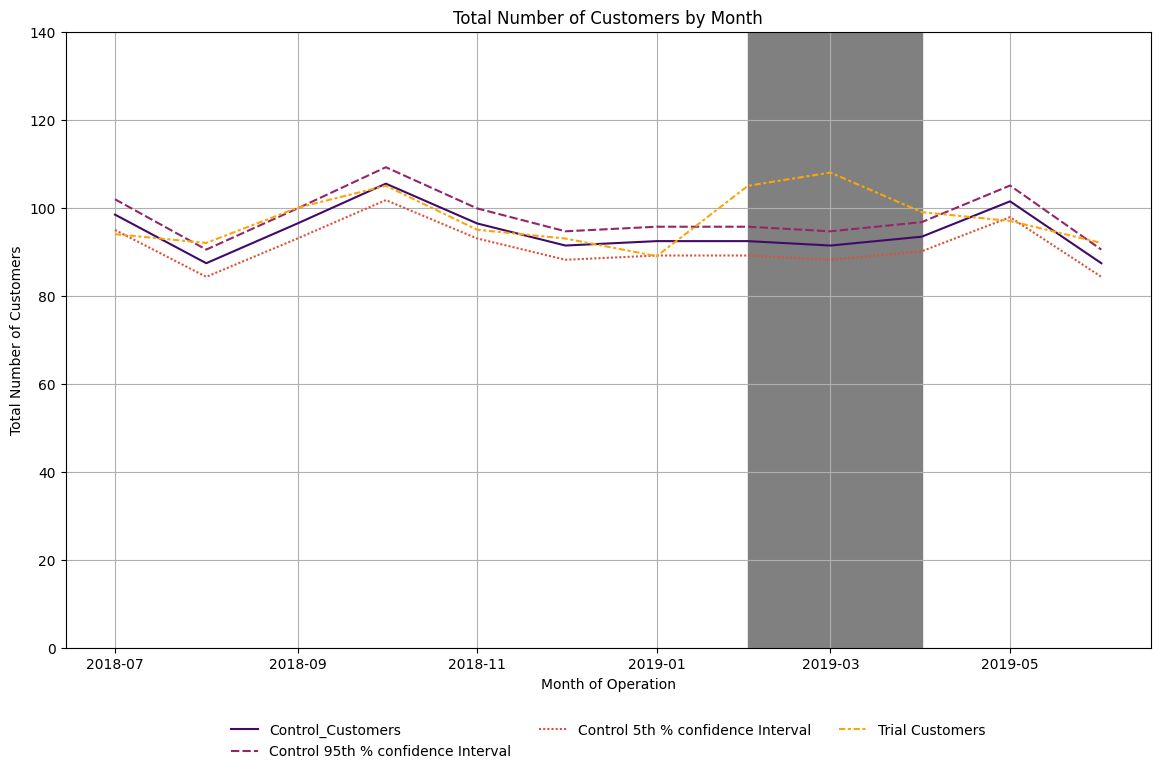

In [109]:
plt.figure(figsize = (14,8))
ax4 = sns.lineplot(data=trial_86_Customer_Assessment, palette = 'inferno')

sns.move_legend(
    ax4, "lower center",
    bbox_to_anchor=(0.5, -.2),
    ncol=3,
    frameon=False,
)

plt.title('Total Number of Customers by Month')
plt.xlabel('Month of Operation')
plt.ylabel('Total Number of Customers')
plt.ylim((0,140))


plt.axvspan(*mdates.datestr2num(['2019-02-01', '2019-04-01']), color = 'grey', alpha = 1)
plt.grid()

**The trial period is highlighted by the grey strip.**

***The number of clients appears to have increased dramatically over the course of the three months. This would appear to indicate that the trial greatly increased the number of patrons in trial shop 86, but as we observed, sales were not significantly higher.***

***We should check with the Category Manager if there were special deals in the trial store that were may have resulted in lower prices, impacting the results.***

# Trial store 88

In [110]:
trial_store = 88

corr_Sales = calculateCorrelation(preTrialMeasures, 'Total Sales', trial_store)
corr_Customers = calculateCorrelation(preTrialMeasures, 'no_Customers', trial_store)

# Compute magnitude with trial store 88
magnitude_Sales = calculateMagnitudeDistance(preTrialMeasures, 'Total Sales', trial_store)
magnitude_Customers = calculateMagnitudeDistance(preTrialMeasures, 'no_Customers', trial_store)

In [111]:
score_Sales = pd.concat([corr_Sales, magnitude_Sales['Magnitude']], axis = 1)
score_Sales

,Store1,Store2,corr_measure,Magnitude
0,88,1,0.786219,0.465210
1,88,2,-0.284971,0.567006
2,88,3,-0.317047,0.468274
3,88,4,-0.329293,0.496586
4,88,5,0.589577,0.572994
...,...,...,...,...
254,88,268,-0.385042,0.543719
255,88,269,0.249978,0.530416
256,88,270,-0.641531,0.571790
257,88,271,0.201224,0.486991


In [112]:
score_Customers = pd.concat([corr_Customers, magnitude_Customers['Magnitude']], axis = 1)

In [113]:
# Add an additional column which calculates the weighted average

corr_weight = 0.5
score_Sales['scoreSales'] = corr_weight * score_Sales['corr_measure'] + (1 - corr_weight) * score_Sales['Magnitude']
score_Customers['scoreCustomers'] = corr_weight * score_Customers['corr_measure'] + (1 - corr_weight) * score_Customers['Magnitude']

In [114]:
score_Sales.set_index(['Store1', 'Store2'], inplace = True)
score_Customers.set_index(['Store1', 'Store2'], inplace = True)

score_Control = pd.concat([score_Sales['scoreSales'], score_Customers['scoreCustomers']], axis = 1)
score_Control

scoreSales  scoreCustomers
Store1 Store2                            
88     1         0.625715        0.401755
       2         0.141017       -0.173420
       3         0.075613        0.517425
       4         0.083647        0.145861
       5         0.581286        0.202205
...                   ...             ...
       268       0.079339        0.581003
       269       0.390197        0.044902
       270      -0.034871        0.015396
       271       0.344108        0.371409
       272       0.240923        0.209911

[259 rows x 2 columns]

In [115]:
# Add a new column 'finalControlScore' to 'score_Control'.

score_Control['finalControlScore'] = 0.5 * (score_Control['scoreSales'] + score_Control['scoreCustomers'])
score_Control

scoreSales  scoreCustomers  finalControlScore
Store1 Store2                                               
88     1         0.625715        0.401755           0.513735
       2         0.141017       -0.173420          -0.016201
       3         0.075613        0.517425           0.296519
       4         0.083647        0.145861           0.114754
       5         0.581286        0.202205           0.391745
...                   ...             ...                ...
       268       0.079339        0.581003           0.330171
       269       0.390197        0.044902           0.217549
       270      -0.034871        0.015396          -0.009737
       271       0.344108        0.371409           0.357759
       272       0.240923        0.209911           0.225417

[259 rows x 3 columns]

In [116]:
score_Control.sort_values(by = 'finalControlScore', ascending = False).head()

scoreSales  scoreCustomers  finalControlScore
Store1 Store2                                               
88     237       0.360413        0.812348           0.586380
       225       0.723701        0.448545           0.586123
       178       0.451170        0.711134           0.581152
       201       0.669019        0.457027           0.563023
       159       0.692517        0.427435           0.559976

We've now found store 237 to be a suitable control store for trial store 88.

Now that we have found a control store, let's check visually if the drivers are indeed similar in the period before the trial.
**texte en gras**

In [117]:
control_store = 237

pastSales = preTrialMeasures

store_type = []

for i in pastSales['STORE_NBR']:
    if i == trial_store:
        store_type.append('Trial Store')
    elif i == control_store:
        store_type.append('Control Store')
    else:
        store_type.append('Other Stores')

pastSales['store_type'] = store_type
pastSales.head()

,STORE_NBR,YEARMONTH,Total Sales,no_Customers,trans_per_customer,chips_per_customer,average_price,store_type,TransactionMonth,Month
0,1,201807,188.9,47,1.042553,1.183673,3.256897,Other Stores,2018-07-01,Jul
1,1,201808,168.4,41,1.000000,1.268293,3.238462,Other Stores,2018-08-01,Aug
2,1,201809,268.1,57,1.035088,1.203390,3.776056,Other Stores,2018-09-01,Sep
3,1,201810,175.4,39,1.025641,1.275000,3.439216,Other Stores,2018-10-01,Oct
4,1,201811,184.8,44,1.022727,1.222222,3.360000,Other Stores,2018-11-01,Nov


In [118]:
controlPlot = pastSales.loc[pastSales['store_type'] == 'Control Store', ['Month', 'Total Sales']]
controlPlot.set_index('Month', inplace = True)

trialPlot = pastSales.loc[pastSales['store_type'] == 'Trial Store', ['Month', 'Total Sales']]
trialPlot.set_index('Month', inplace = True)

otherPlot = pastSales.loc[pastSales['store_type'] == 'Other Stores', ['Month', 'Total Sales']]
otherPlot = pd.DataFrame(otherPlot.groupby('Month')['Total Sales'].mean())

# Renaming Column Names
controlPlot.rename(columns = {'Total Sales': 'Control Store Sales'}, inplace = True)
trialPlot.rename(columns = {'Total Sales': 'Trial Store Sales'}, inplace = True)
otherPlot.rename(columns = {'Total Sales': 'Other Stores Sales'}, inplace = True)

# Concatenate
combinePlot = pd.concat([controlPlot, trialPlot, otherPlot], axis = 1)

combinePlot

,Control Store Sales,Trial Store Sales,Other Stores Sales
Month,,,
Jul,1387.2,1218.2,590.732296
Aug,1260.1,1163.6,538.512840
Sep,1250.8,1361.8,573.436965
Oct,1287.1,1270.8,586.709339
Nov,1316.0,1311.4,571.354475
Dec,1234.4,1213.0,599.002724
Jan,1117.7,1215.4,580.424903


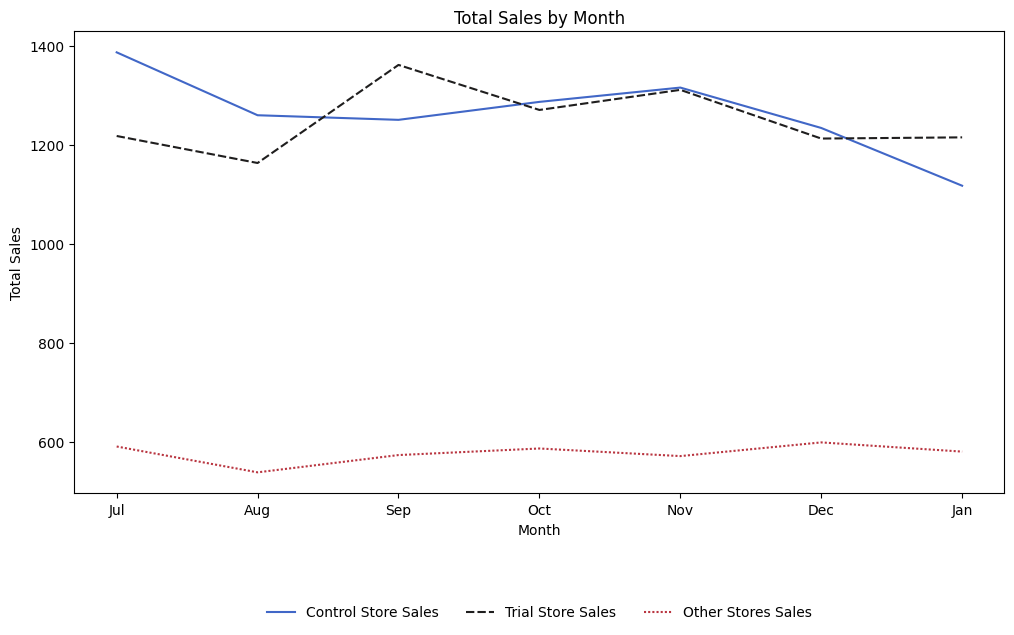

In [119]:
# Plot total Sales for all 3 types of stores


plt.figure(figsize = (12, 6))
plt.title('Total Sales by Month')
ax5 = sns.lineplot(data=combinePlot, palette="icefire")

plt.ylabel("Total Sales")
sns.move_legend(
    ax5, "lower center",
    bbox_to_anchor=(0.5, -.3),
    ncol=3,
    frameon=False,
)

# **Visual checks on customer count trends by comparing the trial store to the control store and other stores.**

In [120]:
control_Customer_Plot = pastSales.loc[pastSales['store_type'] == 'Control Store', ['Month', 'no_Customers']]
control_Customer_Plot.set_index('Month', inplace = True)

trial_Customer_Plot = pastSales.loc[pastSales['store_type'] == 'Trial Store', ['Month', 'no_Customers']]
trial_Customer_Plot.set_index('Month', inplace = True)

other_Customer_Plot = pastSales.loc[pastSales['store_type'] == 'Other Stores', ['Month', 'no_Customers']]
other_Customer_Plot = pd.DataFrame(other_Customer_Plot.groupby('Month')['no_Customers'].mean())

# Renaming Column Names
control_Customer_Plot.rename(columns = {'no_Customers': 'Control Store Customers'}, inplace = True)
trial_Customer_Plot.rename(columns = {'no_Customers': 'Trial Store Customers'}, inplace = True)
other_Customer_Plot.rename(columns = {'no_Customers': 'Other Stores Customers'}, inplace = True)

# Concatenate
combine_Customer_Plot = pd.concat([control_Customer_Plot, trial_Customer_Plot, other_Customer_Plot], axis = 1)

combine_Customer_Plot

,Control Store Customers,Trial Store Customers,Other Stores Customers
Month,,,
Jul,125,124,67.844358
Aug,130,122,66.552529
Sep,120,121,65.988327
Oct,118,120,67.217899
Nov,125,123,66.035019
Dec,121,120,68.750973
Jan,111,115,66.750973


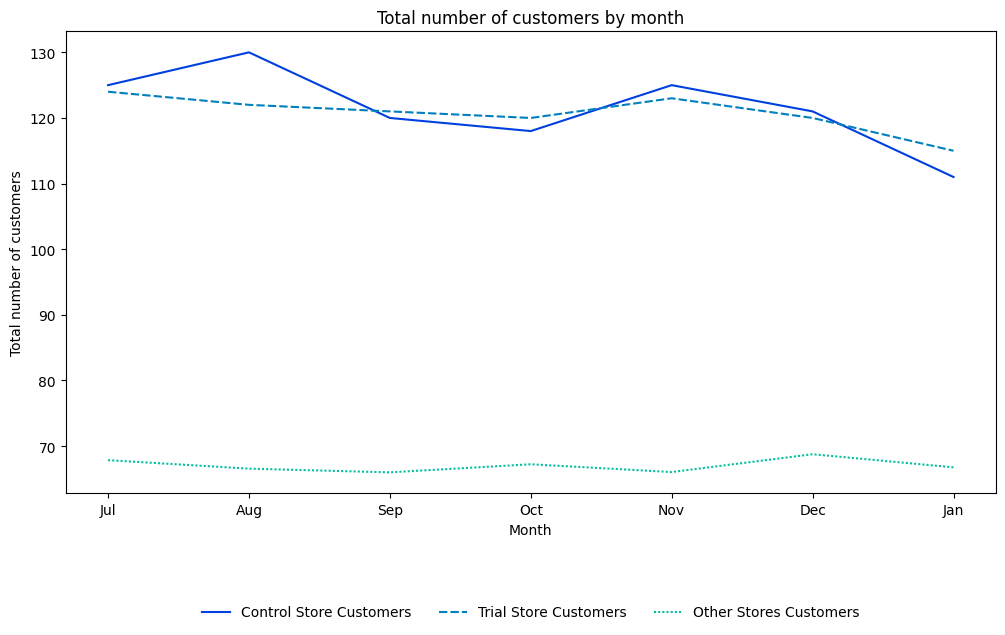

In [121]:
# Plot total number of customers for all 3 types of stores

plt.figure(figsize = (12, 6))
plt.title('Total number of customers by month')
ax6 = sns.lineplot(data=combine_Customer_Plot, palette="winter")

plt.ylabel("Total number of customers")
sns.move_legend(
    ax6, "lower center",
    bbox_to_anchor=(0.5, -.3),
    ncol=3,
    frameon=False,
)

**Assessment of trial**

**The trial period goes from the start of February 2019 to April 2019. We now want to see if there has been an uplift in overall chip sales.**

In [122]:
# Scale pre-trial control sales to match pre-trial trial store sales

trial_sales_sum = preTrialMeasures.loc[preTrialMeasures['store_type'] == 'Trial Store' , 'Total Sales'].sum()
control_sales_sum = preTrialMeasures.loc[preTrialMeasures['store_type'] == 'Control Store' , 'Total Sales'].sum()
scalingFactorForControlSales = trial_sales_sum/ control_sales_sum
scalingFactorForControlSales

np.float64(0.9888064337591632)

In [123]:
# Apply the scaling factor

measureOverTimeSales = measureOverTime
scaledControlSales = measureOverTimeSales.loc[measureOverTimeSales['STORE_NBR'] == control_store]
scaledControlSales['controlSales'] = scaledControlSales['Total Sales'] * scalingFactorForControlSales
scaledControlSales

,STORE_NBR,YEARMONTH,Total Sales,no_Customers,trans_per_customer,chips_per_customer,average_price,TransactionMonth,controlSales
2743,237,201807,1387.2,125,1.248000,2.000000,4.446154,2018-07-01,1371.672285
2744,237,201808,1260.1,130,1.207692,1.866242,4.300683,2018-08-01,1245.994987
2745,237,201809,1250.8,120,1.183333,2.007042,4.388772,2018-09-01,1236.799087
2746,237,201810,1287.1,118,1.194915,2.035461,4.484669,2018-10-01,1272.692761
2747,237,201811,1316.0,125,1.224000,1.986928,4.328947,2018-11-01,1301.269267
2748,237,201812,1234.4,121,1.165289,2.007092,4.361837,2018-12-01,1220.582662
2749,237,201901,1117.7,111,1.162162,1.992248,4.349027,2019-01-01,1105.188951
2750,237,201902,1313.0,119,1.243697,2.000000,4.435811,2019-02-01,1298.302848
2751,237,201903,1177.6,116,1.129310,2.045802,4.394030,2019-03-01,1164.418456
2752,237,201904,1153.6,116,1.120690,2.015385,4.403053,2019-04-01,1140.687102


**Now that we have comparable sales figures for the control store, we can calculate the percentage difference between the scaled control sales and the trial store's sales during the trial period.**

In [124]:
percentageDiff = scaledControlSales[['YEARMONTH','controlSales']]
percentageDiff.reset_index(drop = True, inplace = True)

In [125]:
trial_sales = measureOverTime.loc[measureOverTime['STORE_NBR'] == trial_store , 'Total Sales']
trial_sales.reset_index(drop = True, inplace = True)

percentageDiff = pd.concat([percentageDiff, trial_sales], axis = 1)
percentageDiff.rename(columns = {'Total Sales': 'Trial_Sales'}, inplace = True)
percentageDiff

,YEARMONTH,controlSales,Trial_Sales
0,201807,1371.672285,1218.20
1,201808,1245.994987,1163.60
2,201809,1236.799087,1361.80
3,201810,1272.692761,1270.80
4,201811,1301.269267,1311.40
5,201812,1220.582662,1213.00
6,201901,1105.188951,1215.40
7,201902,1298.302848,1339.60
8,201903,1164.418456,1467.00
9,201904,1140.687102,1317.00


In [126]:
percentageDiff['percentageDiff'] = abs(percentageDiff.controlSales - percentageDiff.Trial_Sales) / percentageDiff.controlSales
percentageDiff

,YEARMONTH,controlSales,Trial_Sales,percentageDiff
0,201807,1371.672285,1218.20,0.111887
1,201808,1245.994987,1163.60,0.066128
2,201809,1236.799087,1361.80,0.101068
3,201810,1272.692761,1270.80,0.001487
4,201811,1301.269267,1311.40,0.007785
5,201812,1220.582662,1213.00,0.006212
6,201901,1105.188951,1215.40,0.099721
7,201902,1298.302848,1339.60,0.031809
8,201903,1164.418456,1467.00,0.259856
9,201904,1140.687102,1317.00,0.154567


**As our null hypothesis is that the trial period is the same as the pre-trial period, let's take the standard deviation based on the scaled percentage difference in the pre-trial period**

In [127]:
stdDev = stdev(percentageDiff.loc[percentageDiff['YEARMONTH'] < 201902, 'percentageDiff'])
stdDev

0.04990490121240933

In [128]:
# Note that there are 8 months in the pre-trial period , Hence 8 - 1 = 7 degrees of freedom
degreesOfFreedom = 7

In [129]:
#### We will test with a null hypothesis of there being 0 difference between trial and control stores.
percentageDiff['tValue'] = (percentageDiff['percentageDiff'] - 0) / stdDev
percentageDiff.loc[(percentageDiff['YEARMONTH'] < 201905 ) & (percentageDiff['YEARMONTH'] > 201901), 'tValue']

,tValue
7,0.637384
8,5.207031
9,3.097236


In [130]:
#### Find the 95th percentile of the t distribution with the degreesOfFreedom = 7

t95 = t.isf(0.05, degreesOfFreedom)
print('95th percentile of the t distribution with the degrees Of Freedom 7   -', t95)

95th percentile of the t distribution with the degrees Of Freedom 7   - 1.8945786050613054


*We can observe that the t-value is much larger than the 95th percentile value of the t-distribution for March and April - i.e. the increase in sales in the trial store in March and April is statistically greater than in the control store.*

In [131]:
measureOverTimeSales = measureOverTime
measureOverTimeSales

,STORE_NBR,YEARMONTH,Total Sales,no_Customers,trans_per_customer,chips_per_customer,average_price,TransactionMonth
0,1,201807,188.9,47,1.042553,1.183673,3.256897,2018-07-01
1,1,201808,168.4,41,1.000000,1.268293,3.238462,2018-08-01
2,1,201809,268.1,57,1.035088,1.203390,3.776056,2018-09-01
3,1,201810,175.4,39,1.025641,1.275000,3.439216,2018-10-01
4,1,201811,184.8,44,1.022727,1.222222,3.360000,2018-11-01
...,...,...,...,...,...,...,...,...
3160,272,201902,385.3,44,1.068182,1.893617,4.329213,2019-02-01
3161,272,201903,421.9,48,1.062500,1.901961,4.349485,2019-03-01
3162,272,201904,445.1,54,1.018519,1.909091,4.239048,2019-04-01
3163,272,201905,314.6,34,1.176471,1.775000,4.430986,2019-05-01


In [132]:
#### Trial and control store total sales

pastSales = measureOverTimeSales.loc[measureOverTimeSales['STORE_NBR'] == trial_store, ['TransactionMonth', 'Total Sales']]
pastSales.set_index('TransactionMonth', inplace = True)
pastSales.rename(columns = {'Total Sales': 'Trial Sales'}, inplace = True)
pastSales

,Trial Sales
TransactionMonth,
2018-07-01,1218.20
2018-08-01,1163.60
2018-09-01,1361.80
2018-10-01,1270.80
2018-11-01,1311.40
2018-12-01,1213.00
2019-01-01,1215.40
2019-02-01,1339.60
2019-03-01,1467.00


In [133]:
#### Control store 95th percentile

controlSales = scaledControlSales.loc[:, ['TransactionMonth', 'controlSales']]
controlSales.set_index('TransactionMonth', inplace = True)
controlSales.rename(columns = {'controlSales': 'Control Sales'}, inplace = True)
controlSales

,Control Sales
TransactionMonth,
2018-07-01,1371.672285
2018-08-01,1245.994987
2018-09-01,1236.799087
2018-10-01,1272.692761
2018-11-01,1301.269267
2018-12-01,1220.582662
2019-01-01,1105.188951
2019-02-01,1298.302848
2019-03-01,1164.418456


In [134]:
#### Control store 95th percentile
controlSales['Control store 95th percentile'] = controlSales['Control Sales'] * (1 + stdDev*2)

#### Control store 5th percentile

controlSales['Control store 5th percentile'] = controlSales['Control Sales'] * (1 - stdDev*2)

controlSales

,Control Sales,Control store 95th percentile,Control store 5th percentile
TransactionMonth,,,
2018-07-01,1371.672285,1508.578625,1234.765945
2018-08-01,1245.994987,1370.357501,1121.632474
2018-09-01,1236.799087,1360.243760,1113.354415
2018-10-01,1272.692761,1399.719974,1145.665548
2018-11-01,1301.269267,1431.148695,1171.389838
2018-12-01,1220.582662,1342.408776,1098.756548
2019-01-01,1105.188951,1215.497642,994.880260
2019-02-01,1298.302848,1427.886198,1168.719497
2019-03-01,1164.418456,1280.638832,1048.198080


In [135]:
trialAssessment = pd.merge(controlSales, pastSales, left_index = True, right_index = True)
trialAssessment

,Control Sales,Control store 95th percentile,Control store 5th percentile,Trial Sales
TransactionMonth,,,,
2018-07-01,1371.672285,1508.578625,1234.765945,1218.20
2018-08-01,1245.994987,1370.357501,1121.632474,1163.60
2018-09-01,1236.799087,1360.243760,1113.354415,1361.80
2018-10-01,1272.692761,1399.719974,1145.665548,1270.80
2018-11-01,1301.269267,1431.148695,1171.389838,1311.40
2018-12-01,1220.582662,1342.408776,1098.756548,1213.00
2019-01-01,1105.188951,1215.497642,994.880260,1215.40
2019-02-01,1298.302848,1427.886198,1168.719497,1339.60
2019-03-01,1164.418456,1280.638832,1048.198080,1467.00


* *Let’s create a more visual version of this by plotting the sales of the control store, the sales of the trial stores and the 95th percentile value of sales of the control store.*

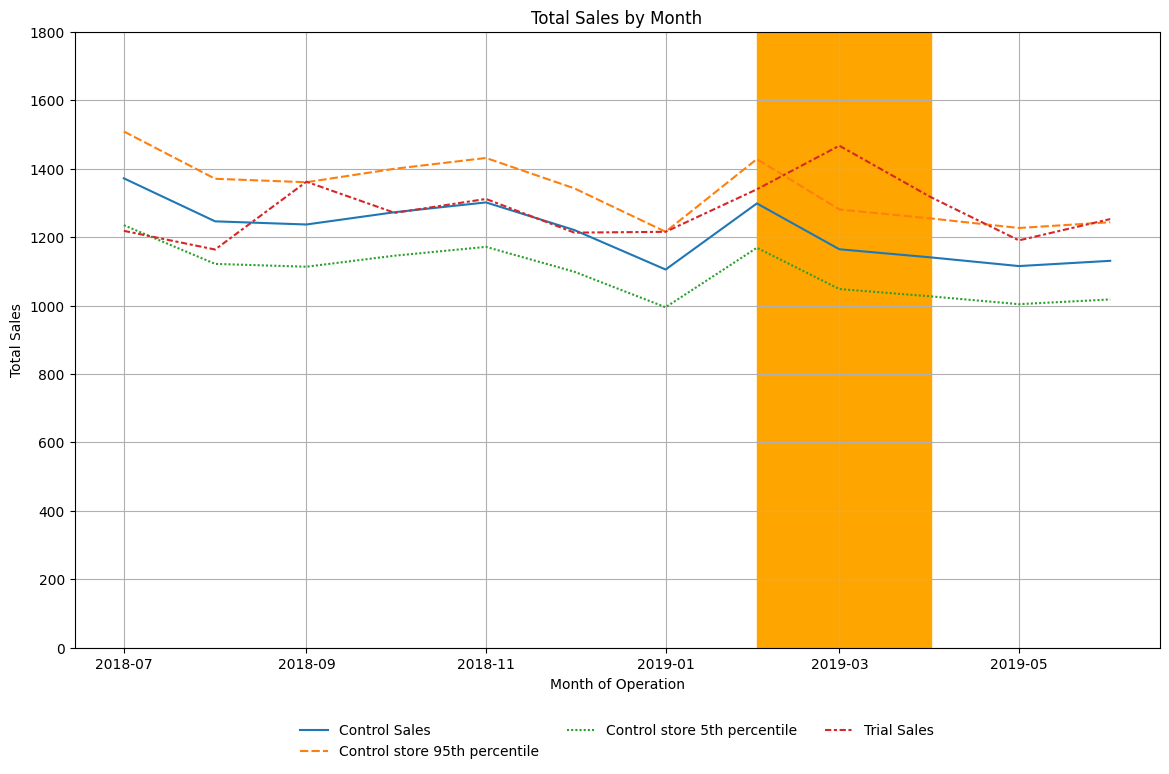

In [136]:
plt.figure(figsize = (14,8))
ax7 = sns.lineplot(data=trialAssessment)

sns.move_legend(
    ax7, "lower center",
    bbox_to_anchor=(0.5, -.2),
    ncol=3,
    frameon=False,
)

plt.title('Total Sales by Month')
plt.xlabel('Month of Operation')
plt.ylabel('Total Sales')
plt.ylim((0, 1800))


plt.axvspan(*mdates.datestr2num(['2019-02-01', '2019-04-01']), color = 'orange', alpha = 1)
plt.grid()

**The trial period is highlighted by the orange strip.**

***The results show that the trial in store 88 is significantly different to its control store in the trial period as the trial store performance lies outside the 5% to 95% confidence interval of the control store in two of the three trial months.***

**Let's have a look at assessing this for number of customers as well.**

In [137]:
trial_customers = preTrialMeasures.loc[preTrialMeasures['store_type'] == 'Trial Store' , 'no_Customers'].sum()
control_customers = preTrialMeasures.loc[preTrialMeasures['store_type'] == 'Control Store', 'no_Customers'].sum()
scalingFactorForControlCust = trial_customers / control_customers
scalingFactorForControlCust

np.float64(0.9941176470588236)

In [138]:
measureOverTimeCusts = measureOverTime
measureOverTimeCusts

,STORE_NBR,YEARMONTH,Total Sales,no_Customers,trans_per_customer,chips_per_customer,average_price,TransactionMonth
0,1,201807,188.9,47,1.042553,1.183673,3.256897,2018-07-01
1,1,201808,168.4,41,1.000000,1.268293,3.238462,2018-08-01
2,1,201809,268.1,57,1.035088,1.203390,3.776056,2018-09-01
3,1,201810,175.4,39,1.025641,1.275000,3.439216,2018-10-01
4,1,201811,184.8,44,1.022727,1.222222,3.360000,2018-11-01
...,...,...,...,...,...,...,...,...
3160,272,201902,385.3,44,1.068182,1.893617,4.329213,2019-02-01
3161,272,201903,421.9,48,1.062500,1.901961,4.349485,2019-03-01
3162,272,201904,445.1,54,1.018519,1.909091,4.239048,2019-04-01
3163,272,201905,314.6,34,1.176471,1.775000,4.430986,2019-05-01


In [139]:
scaledControlCustomers = measureOverTimeCusts.loc[measureOverTimeCusts['STORE_NBR'] == control_store]
scaledControlCustomers

,STORE_NBR,YEARMONTH,Total Sales,no_Customers,trans_per_customer,chips_per_customer,average_price,TransactionMonth
2743,237,201807,1387.2,125,1.248000,2.000000,4.446154,2018-07-01
2744,237,201808,1260.1,130,1.207692,1.866242,4.300683,2018-08-01
2745,237,201809,1250.8,120,1.183333,2.007042,4.388772,2018-09-01
2746,237,201810,1287.1,118,1.194915,2.035461,4.484669,2018-10-01
2747,237,201811,1316.0,125,1.224000,1.986928,4.328947,2018-11-01
2748,237,201812,1234.4,121,1.165289,2.007092,4.361837,2018-12-01
2749,237,201901,1117.7,111,1.162162,1.992248,4.349027,2019-01-01
2750,237,201902,1313.0,119,1.243697,2.000000,4.435811,2019-02-01
2751,237,201903,1177.6,116,1.129310,2.045802,4.394030,2019-03-01
2752,237,201904,1153.6,116,1.120690,2.015385,4.403053,2019-04-01


In [140]:
scaledControlCustomers['Control_Customers'] = scaledControlCustomers['no_Customers'] * scalingFactorForControlCust
scaledControlCustomers

,STORE_NBR,YEARMONTH,Total Sales,no_Customers,trans_per_customer,chips_per_customer,average_price,TransactionMonth,Control_Customers
2743,237,201807,1387.2,125,1.248000,2.000000,4.446154,2018-07-01,124.264706
2744,237,201808,1260.1,130,1.207692,1.866242,4.300683,2018-08-01,129.235294
2745,237,201809,1250.8,120,1.183333,2.007042,4.388772,2018-09-01,119.294118
2746,237,201810,1287.1,118,1.194915,2.035461,4.484669,2018-10-01,117.305882
2747,237,201811,1316.0,125,1.224000,1.986928,4.328947,2018-11-01,124.264706
2748,237,201812,1234.4,121,1.165289,2.007092,4.361837,2018-12-01,120.288235
2749,237,201901,1117.7,111,1.162162,1.992248,4.349027,2019-01-01,110.347059
2750,237,201902,1313.0,119,1.243697,2.000000,4.435811,2019-02-01,118.300000
2751,237,201903,1177.6,116,1.129310,2.045802,4.394030,2019-03-01,115.317647
2752,237,201904,1153.6,116,1.120690,2.015385,4.403053,2019-04-01,115.317647


In [141]:
# Calculate the percentage difference between scaled control customers. and trial customers.

percentageDiff = scaledControlCustomers[['YEARMONTH','Control_Customers']]
percentageDiff.reset_index(drop = True, inplace = True)
percentageDiff

,YEARMONTH,Control_Customers
0,201807,124.264706
1,201808,129.235294
2,201809,119.294118
3,201810,117.305882
4,201811,124.264706
5,201812,120.288235
6,201901,110.347059
7,201902,118.300000
8,201903,115.317647
9,201904,115.317647


In [142]:
trial_Customers = measureOverTimeCusts.loc[measureOverTimeCusts['STORE_NBR'] == trial_store, 'no_Customers']
trial_Customers.reset_index(drop = True, inplace = True)
trial_Customers

,no_Customers
0,124
1,122
2,121
3,120
4,123
5,120
6,115
7,122
8,133
9,119


In [143]:
percentageDiff = pd.concat([percentageDiff, trial_Customers], axis = 1)
percentageDiff.rename(columns = {'no_Customers': 'Trial_Customers'}, inplace = True)
percentageDiff

,YEARMONTH,Control_Customers,Trial_Customers
0,201807,124.264706,124
1,201808,129.235294,122
2,201809,119.294118,121
3,201810,117.305882,120
4,201811,124.264706,123
5,201812,120.288235,120
6,201901,110.347059,115
7,201902,118.300000,122
8,201903,115.317647,133
9,201904,115.317647,119


In [146]:
percentageDiff['percentageDiff'] = abs(percentageDiff.Control_Customers - percentageDiff.Trial_Customers) / percentageDiff.Control_Customers
percentageDiff

,YEARMONTH,Control_Customers,Trial_Customers,percentageDiff
0,201807,124.264706,124,0.002130
1,201808,129.235294,122,0.055985
2,201809,119.294118,121,0.014300
3,201810,117.305882,120,0.022967
4,201811,124.264706,123,0.010178
5,201812,120.288235,120,0.002396
6,201901,110.347059,115,0.042166
7,201902,118.300000,122,0.031276
8,201903,115.317647,133,0.153336
9,201904,115.317647,119,0.031932


**Let’s again see if the difference is significant visually!**

In [145]:
percentageDiff['percentageDiff'] = abs(percentageDiff.Control_Customers - percentageDiff.Trial_Customers) / percentageDiff.Control_Customers
stdDev = stdev(percentageDiff.loc[percentageDiff['YEARMONTH'] < 201902, 'percentageDiff'])

degreesOfFreedom = 7

**As our null hypothesis is that the trial period is the same as the pre‐trial period, let's take the standard deviation based on the scaledpercentage difference in the pre‐trial period**

In [147]:
percentageDiff['T_value'] = (percentageDiff['percentageDiff'] - 0) / stdDev
percentageDiff.loc[(percentageDiff['YEARMONTH'] > 201901) & (percentageDiff['YEARMONTH'] < 201905), 'T_value']

,T_value
7,1.520513
8,7.454480
9,1.552397


In [148]:
#### Find the 95th percentile of the t distribution with the degreesOfFreedom = 7

t95 = t.isf(0.05, degreesOfFreedom)
print('95th percentile of the t distribution with the degrees Of Freedom 7   -', t95)

95th percentile of the t distribution with the degrees Of Freedom 7   - 1.8945786050613054


*We Can see that the t-value is much greater than the 95th percentile of the t distribution*

In [149]:
controlCustomers = scaledControlCustomers.loc[:, ['TransactionMonth', 'Control_Customers']]
controlCustomers.set_index('TransactionMonth', inplace = True)
controlCustomers

,Control_Customers
TransactionMonth,
2018-07-01,124.264706
2018-08-01,129.235294
2018-09-01,119.294118
2018-10-01,117.305882
2018-11-01,124.264706
2018-12-01,120.288235
2019-01-01,110.347059
2019-02-01,118.300000
2019-03-01,115.317647


In [150]:
trialCustomers = measureOverTimeCusts.loc[measureOverTimeCusts['STORE_NBR'] == trial_store, ['TransactionMonth', 'no_Customers']]
trialCustomers.set_index('TransactionMonth', inplace = True)
trialCustomers.rename(columns = {'no_Customers': 'Trial Customers'}, inplace = True)
trialCustomers

,Trial Customers
TransactionMonth,
2018-07-01,124
2018-08-01,122
2018-09-01,121
2018-10-01,120
2018-11-01,123
2018-12-01,120
2019-01-01,115
2019-02-01,122
2019-03-01,133


In [153]:
#### Control store 95th percentile
controlCustomers['Control 95th % confidence Interval'] = controlCustomers['Control_Customers'] * (1 + stdDev*2)
controlCustomers['Control 5th % confidence Interval'] = controlCustomers['Control_Customers'] * (1 - stdDev*2)

# Merge trial store as well to the control store dataframe.
trial_88_Customer_Assessment = pd.merge(controlCustomers, trialCustomers, left_index = True, right_index = True)

In [154]:
trial_88_Customer_Assessment

,Control_Customers,Control 95th % confidence Interval,Control 5th % confidence Interval,Trial Customers
TransactionMonth,,,,
2018-07-01,124.264706,129.376869,119.152542,124
2018-08-01,129.235294,134.551944,123.918644,122
2018-09-01,119.294118,124.201795,114.386441,121
2018-10-01,117.305882,122.131765,112.480000,120
2018-11-01,124.264706,129.376869,119.152542,123
2018-12-01,120.288235,125.236810,115.339661,120
2019-01-01,110.347059,114.886660,105.807458,115
2019-02-01,118.300000,123.166780,113.433220,122
2019-03-01,115.317647,120.061735,110.573559,133


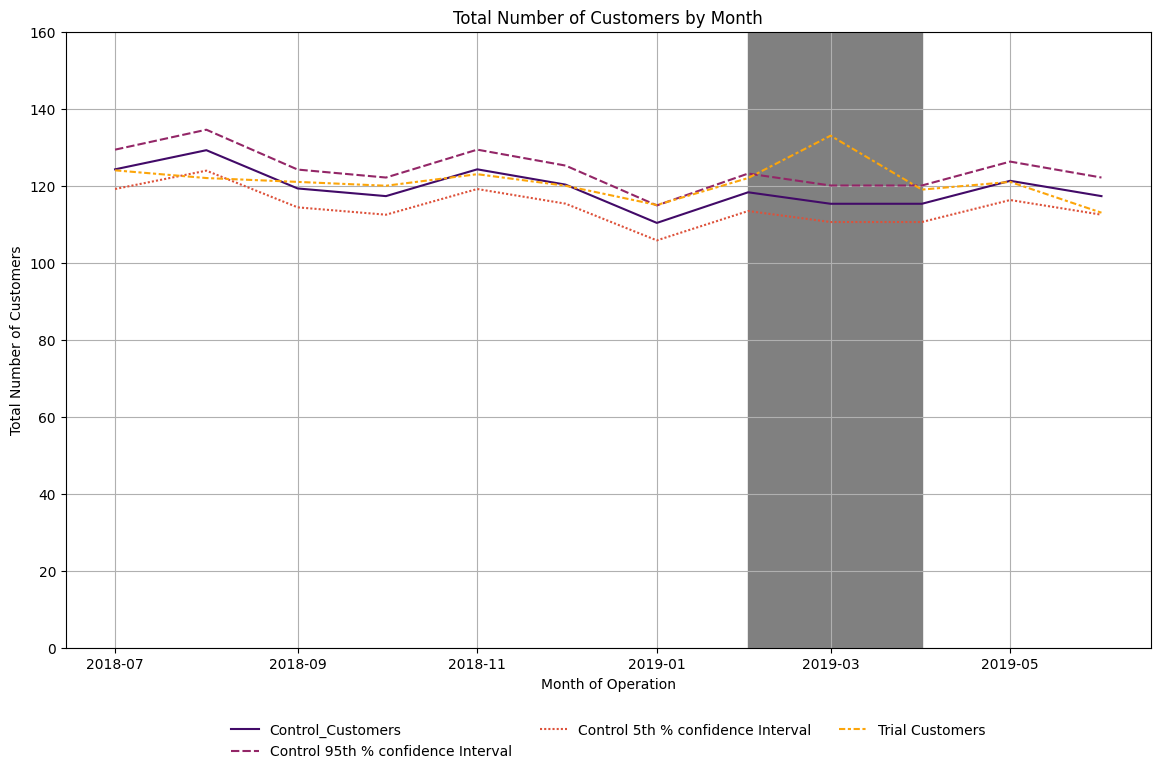

In [155]:
plt.figure(figsize = (14,8))
ax8 = sns.lineplot(data=trial_88_Customer_Assessment, palette = 'inferno')

sns.move_legend(
    ax8, "lower center",
    bbox_to_anchor=(0.5, -.2),
    ncol=3,
    frameon=False,
)

plt.title('Total Number of Customers by Month')
plt.xlabel('Month of Operation')
plt.ylabel('Total Number of Customers')
plt.ylim((0, 160))


plt.axvspan(*mdates.datestr2num(['2019-02-01', '2019-04-01']), color = 'grey', alpha = 1)
plt.grid()

**The trial period is highlighted by the grey strip**

***Total number of customers in the trial period for the trial store is significantly higher than the control store or two out of three months, which indicates a positive trial effect.***

# Conclusion

* We've found control stores 233, 155, 237 for trial stores 77, 86 and 88 respectively.
* The results for trial stores 77 and 88 during the trial period show a significant difference in at least two of the three trial months but this is not the case for trial store 86. We can check with the client if the implementation of the trial was different in trial store 86 but overall, the trial shows a significant increase in sales.
* Now that we have finished our analysis, we can prepare our presentation to the Category Manager.